# Análise consolidada de eventos LHE com pandas.DataFrame

Notebook público de roteiro para estudantes do repositório-exemplo da disciplina FIS01214. Ele demonstra uma análise completa do canal de Higgs em dois fótons. A análise percorre as Partes 1 e 2 usando `pandas.DataFrame` como estrutura principal, com células executadas, tabelas, gráficos e resultados numéricos preservados quando este notebook for executado no CERN SWAN. Os outputs devem ser preservados na cópia publicada do exemplo.

## Ambientes suportados

- CERN SWAN: clone o repositório pela interface usando sua URL HTTPS, instale as dependências se necessário e execute o notebook a partir do clone.

Dependências mínimas: `numpy`, `pandas`, PyROOT (`ROOT`) e `IPython`. Este notebook não depende de `pylhe`; a leitura é feita diretamente com Python e convertida para DataFrames.


## Processo demonstrado

Este exemplo usa as amostras de Higgs em dois fótons: sinal `pp → H → γγ` e fundo `pp → γγ` sem contribuição do Higgs. O objetivo é mostrar uma análise completa em nível de gerador, incluindo seleção, distribuições cinemáticas, massa invariante, normalização e interpretação das limitações detectoras.


### Objetivo desta célula

Verifica e instala no kernel do SWAN apenas as dependências Python necessárias. O resultado confirma que o ambiente consegue executar a análise sem modificar os arquivos LHE.


In [1]:
# CERN SWAN: verificar e instalar dependências no kernel atual
import importlib.util
import subprocess, sys
pacotes = {"numpy": "numpy", "pandas": "pandas", "matplotlib": "matplotlib", "ROOT": "ROOT", "IPython": "ipython"}
ausentes = [pip for modulo, pip in pacotes.items() if importlib.util.find_spec(modulo) is None]
if ausentes:
    print("Instalando no kernel SWAN:", ausentes)
    subprocess.check_call([sys.executable, "-m", "pip", "install", *ausentes])
else:
    print("Todas as dependências já estão disponíveis.")
for modulo in pacotes:
    modulo_import = "IPython" if modulo == "IPython" else modulo
    print(modulo, importlib.import_module(modulo_import).__version__ if modulo_import != "IPython" else "disponível")


Todas as dependências já estão disponíveis.
numpy 2.5.2


pandas 3.0.5
matplotlib 3.11.1


ROOT 6.40.04
IPython disponível


# Projeto Final - Análise de eventos LHE - referência comentada

## Parte 1: Leitura do LHE para `pandas.DataFrame`

Este notebook contem uma solucao de referência para a abordagem **pandas.DataFrame**.
Ele inclui código completo e respostas de conferencia para a Parte 1.


## 0. Preparação no CERN SWAN

Na interface do CERN SWAN, clone este repositório usando a URL HTTPS `https://github.com/FIS01214/análise-swan.git`. Abra o notebook a partir da pasta clonada.

Depois, peça ao agente os códigos de cada etapa indicada neste notebook e copie-os nas células de código correspondentes. Os arquivos `data/sinal.lhe.gz` e `data/fundo.lhe.gz` já estão no clone; eles podem ser lidos diretamente com `gzip.open`, sem baixar ZIP, fazer upload ou descompactar o repositório.

Execute primeiro a célula de instalação/verificação de dependências e mantenha os caminhos relativos aos arquivos de dados.

Preparamos dependências e caminhos para garantir uma análise reproduzível no kernel SWAN.


## Organização e roteiro

O notebook segue os quatro itens de `parte1.txt`:

1. leitura dos arquivos LHE;
2. contagem dos eventos e tabela de partículas por `status`;
3. histogramas de $p_T$, $\eta$ e $\phi$ para as partículas finais visíveis;
4. estudo de cortes cinemáticos e reconstrução dos histogramas após a seleção.

> Execute as células na ordem. O notebook localiza automaticamente a raiz do projeto quando é aberto a partir da pasta `notebooks/` ou da raiz do workdir.

Cada bloco `<event>` representa uma colisão e guarda partículas, códigos PDG, estados e quadrimomentos. Seguiremos o caminho natural de uma análise do LHC: ler o formato, validar a amostra, construir observáveis, aplicar a seleção e só então interpretar yields e significância.


### Objetivo desta célula

Importa as bibliotecas, localiza a raiz do projeto e define os caminhos das amostras. O resultado prepara o ambiente e confirma onde `sinal.lhe.gz` e `fundo.lhe.gz` serão lidos.


In [2]:
from collections import Counter
from dataclasses import dataclass
from pathlib import Path
import gzip
import math
import re

from root_plotting import plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

pd.set_option("display.max_rows", 100)

def localizar_raiz():
    candidatos = [Path.cwd(), *Path.cwd().parents]
    for candidato in candidatos:
        if (candidato / "data" / "sinal.lhe.gz").exists():
            return candidato.resolve()
    raise FileNotFoundError(
        "Não encontrei data/sinal.lhe.gz. Abra o notebook a partir da raiz "
        "do projeto ou da pasta notebooks/."
    )

RAIZ = localizar_raiz()
PASTA_DADOS = RAIZ / "data"
PASTA_GRAFICOS = RAIZ / "resultados" / "graficos"
PASTA_GRAFICOS.mkdir(parents=True, exist_ok=True)

ARQUIVOS = {
    "Sinal": PASTA_DADOS / "sinal.lhe.gz",
    "Fundo": PASTA_DADOS / "fundo.lhe.gz",
}

print(f"Raiz do projeto: {RAIZ}")
for amostra, caminho in ARQUIVOS.items():
    tamanho_mb = caminho.stat().st_size / 1024**2
    print(f"{amostra:5s}: {caminho.name} ({tamanho_mb:.2f} MB)")

Raiz do projeto: /private/var/folders/83/nqg6t5253dzbzhl2t658y2p80000gn/T/tmp.8IWRr49Oyc
Sinal: sinal.lhe.gz (1.10 MB)
Fundo: fundo.lhe.gz (0.93 MB)


## 1. Leitura dos arquivos LHE

Um bloco `<event>` começa com uma linha de cabeçalho. O primeiro número dessa linha informa quantas partículas pertencem ao evento. Cada linha seguinte contém, entre outras informações, o identificador PDG, o `status`, as componentes do momento $(p_x,p_y,p_z)$, a energia e a massa.

Nesta etapa transformamos o registro textual em objetos que representam a física do evento. Para cada partícula conservamos o quadrimomento $(E,p_x,p_y,p_z)$ e o identificador PDG; essas informações permitem calcular massas, ângulos e momentos sem perder a ligação com o processo gerado.


### Objetivo desta célula

Lê e imprime o primeiro bloco `<event>` da amostra de sinal. O resultado permite reconhecer visualmente o cabeçalho do evento e as linhas de partículas antes da leitura estruturada.


In [3]:
def imprimir_primeiro_bloco_evento(caminho):
    """Imprime o primeiro bloco <event> completo do arquivo LHE."""
    linhas_evento = []
    dentro_evento = False
    with gzip.open(caminho, "rt", encoding="utf-8", errors="replace") as arquivo:
        for linha in arquivo:
            if linha.strip() == "<event>":
                dentro_evento = True
            if dentro_evento:
                linhas_evento.append(linha.rstrip("\n"))
            if dentro_evento and linha.strip() == "</event>":
                break
    if not linhas_evento or linhas_evento[-1].strip() != "</event>":
        raise ValueError(f"Nenhum bloco <event> completo encontrado em {caminho}")
    print("\n".join(linhas_evento))

imprimir_primeiro_bloco_evento(ARQUIVOS["Sinal"])


<event>
 5      1 +1.8607000e-02 1.25001300e+02 7.54677100e-03 1.23506700e-01
       21 -1    0    0  502  501 +0.0000000000e+00 +0.0000000000e+00 +1.0384995399e+02 1.0384995399e+02 0.0000000000e+00 0.0000e+00 1.0000e+00
       21 -1    0    0  501  502 -0.0000000000e+00 -0.0000000000e+00 -3.7615171905e+01 3.7615171905e+01 0.0000000000e+00 0.0000e+00 1.0000e+00
       25  2    1    2    0    0 +0.0000000000e+00 +0.0000000000e+00 +6.6234782085e+01 1.4146512589e+02 1.2500134194e+02 0.0000e+00 9.0000e+00
       22  1    3    3    0    0 +5.3205387804e+01 -3.2691023760e+01 +3.6072331592e+01 7.2116083035e+01 0.0000000000e+00 0.0000e+00 -1.0000e+00
       22  1    3    3    0    0 -5.3205387804e+01 +3.2691023760e+01 +3.0162450492e+01 6.9349042859e+01 0.0000000000e+00 0.0000e+00 -1.0000e+00
</event>


Agora usaremos `gzip.open` para ler os arquivos compactados sem criar cópias descompactadas.


### Objetivo desta célula

Define funções para abrir arquivos LHE normais ou compactados e extrair o processo registrado no cartão do MadGraph. O resultado identifica a origem física de cada amostra.


In [4]:
def abrir_lhe(caminho):
    caminho = Path(caminho)
    if caminho.suffix == ".gz":
        return gzip.open(caminho, "rt", encoding="utf-8", errors="replace")
    return caminho.open("rt", encoding="utf-8", errors="replace")

def extrair_processo_madgraph(caminho):
    trecho = []
    dentro_do_cartao = False
    with abrir_lhe(caminho) as arquivo:
        for linha in arquivo:
            if "<MG5ProcCard>" in linha:
                dentro_do_cartao = True
            elif "</MG5ProcCard>" in linha:
                break
            elif dentro_do_cartao:
                trecho.append(linha)
    comandos = re.findall(r"^\s*generate\s+(.+?)\s*$", "".join(trecho), re.MULTILINE)
    return comandos[-1] if comandos else "processo não identificado"

for amostra, caminho in ARQUIVOS.items():
    print(f"{amostra}: {extrair_processo_madgraph(caminho)}")


Sinal: p p > h > a a
Fundo: p p > a a / h


### Objetivo desta célula

Percorre os dois arquivos LHE e transforma cabeçalhos de eventos e partículas em DataFrames. O resultado é a estrutura tabular usada nas etapas seguintes.


In [5]:
def ler_lhe_para_dataframes(arquivos):
    eventos = []
    particulas = []

    for amostra, caminho in arquivos.items():
        dentro_evento = False
        esperando_cabecalho = False
        restantes = 0
        indice_evento = 0

        with abrir_lhe(caminho) as arquivo:
            for numero_linha, linha in enumerate(arquivo, start=1):
                linha = linha.strip()
                if linha == "<event>":
                    dentro_evento = True
                    esperando_cabecalho = True
                    restantes = 0
                    indice_evento += 1
                    continue
                if not dentro_evento:
                    continue
                if esperando_cabecalho:
                    if not linha or linha.startswith("#"):
                        continue
                    campos = linha.split()
                    if len(campos) < 6:
                        raise ValueError(f"Cabeçalho inválido na linha {numero_linha}")
                    nup = int(campos[0])
                    eventos.append({
                        "Amostra": amostra,
                        "Evento": indice_evento,
                        "NUP": nup,
                        "IDPRUP": int(campos[1]),
                        "peso_evento": float(campos[2]),
                        "SCALUP": float(campos[3]),
                        "AQEDUP": float(campos[4]),
                        "AQCDUP": float(campos[5]),
                    })
                    restantes = nup
                    esperando_cabecalho = False
                    continue
                if restantes > 0:
                    campos = linha.split()
                    if len(campos) < 13:
                        raise ValueError(f"Partícula inválida na linha {numero_linha}")
                    particulas.append({
                        "Amostra": amostra,
                        "Evento": indice_evento,
                        "PDG ID": int(campos[0]),
                        "status": int(campos[1]),
                        "mae_1": int(campos[2]),
                        "mae_2": int(campos[3]),
                        "cor_1": int(campos[4]),
                        "cor_2": int(campos[5]),
                        "px": float(campos[6]),
                        "py": float(campos[7]),
                        "pz": float(campos[8]),
                        "energia": float(campos[9]),
                        "massa": float(campos[10]),
                        "tempo_vida": float(campos[11]),
                        "spin": float(campos[12]),
                    })
                    restantes -= 1
                    if restantes == 0:
                        dentro_evento = False

    eventos_df = pd.DataFrame(eventos)
    particulas_df = pd.DataFrame(particulas)
    particulas_df["pT [GeV]"] = np.hypot(particulas_df["px"], particulas_df["py"])
    particulas_df["eta"] = np.arcsinh(particulas_df["pz"] / particulas_df["pT [GeV]"].replace(0, np.nan))
    particulas_df["phi"] = np.arctan2(particulas_df["py"], particulas_df["px"])
    return eventos_df, particulas_df

eventos_df, particulas_df = ler_lhe_para_dataframes(ARQUIVOS)
display(eventos_df.head())
display(particulas_df.head())

@dataclass(frozen=True)
class Particula:
    pdg_id: int
    status: int
    mae_1: int
    mae_2: int
    cor_1: int
    cor_2: int
    px: float
    py: float
    pz: float
    energia: float
    massa: float
    tempo_vida: float
    spin: float
    eficiencia: float = 1.0
    reconstruida: bool = True

    @property
    def pt(self):
        return math.hypot(self.px, self.py)

    @property
    def eta(self):
        if self.pt == 0:
            return math.copysign(math.inf, self.pz)
        return math.asinh(self.pz / self.pt)

    @property
    def phi(self):
        return math.atan2(self.py, self.px)

@dataclass(frozen=True)
class Evento:
    processo_id: int
    peso: float
    escala: float
    alpha_qed: float
    alpha_qcd: float
    particulas: tuple

def converter_dataframes_para_eventos(eventos_df, particulas_df):
    eventos_por_amostra = {}
    for amostra, tabela_eventos in eventos_df.groupby("Amostra", sort=False):
        lista = []
        tabela_particulas_amostra = particulas_df[particulas_df["Amostra"] == amostra]
        for linha_evento in tabela_eventos.itertuples(index=False):
            partes = tabela_particulas_amostra[tabela_particulas_amostra["Evento"] == linha_evento.Evento]
            particulas = tuple(
                Particula(
                    pdg_id=int(linha["PDG ID"]),
                    status=int(linha["status"]),
                    mae_1=int(linha["mae_1"]),
                    mae_2=int(linha["mae_2"]),
                    cor_1=int(linha["cor_1"]),
                    cor_2=int(linha["cor_2"]),
                    px=float(linha["px"]),
                    py=float(linha["py"]),
                    pz=float(linha["pz"]),
                    energia=float(linha["energia"]),
                    massa=float(linha["massa"]),
                    tempo_vida=float(linha["tempo_vida"]),
                    spin=float(linha["spin"]),
                    eficiencia=float(linha.get("eficiencia", 1.0)),
                    reconstruida=bool(linha.get("reconstruida", True)),
                )
                for _, linha in partes.iterrows()
            )
            dados_evento = linha_evento._asdict()
            lista.append(Evento(
                processo_id=int(dados_evento["IDPRUP"]),
                peso=float(dados_evento["peso_evento"]),
                escala=float(dados_evento["SCALUP"]),
                alpha_qed=float(dados_evento["AQEDUP"]),
                alpha_qcd=float(dados_evento["AQCDUP"]),
                particulas=particulas,
            ))
        eventos_por_amostra[amostra] = lista
    return eventos_por_amostra

def ler_lhe(caminho):
    raise RuntimeError("Nesta versão, use `eventos_df` e `particulas_df`; `eventos` já foi construído a partir dos DataFrames.")

eventos = converter_dataframes_para_eventos(eventos_df, particulas_df)


,Amostra,Evento,NUP,IDPRUP,peso_evento,SCALUP,AQEDUP,AQCDUP
0,Sinal,1,5,1,0.018607,125.0013,0.007547,0.123507
1,Sinal,2,5,1,0.018607,125.0007,0.007547,0.123507
2,Sinal,3,5,1,0.018607,124.9997,0.007547,0.123507
3,Sinal,4,5,1,0.018607,124.9959,0.007547,0.123508
4,Sinal,5,5,1,0.018607,124.9804,0.007547,0.123510


,Amostra,Evento,PDG ID,status,mae_1,mae_2,cor_1,cor_2,px,py,pz,energia,massa,tempo_vida,spin,pT [GeV],eta,phi
0,Sinal,1,21,-1,0,0,502,501,0.000000,0.000000,103.849954,103.849954,0.000000,0.0,1.0,0.000000,NaN,0.000000
1,Sinal,1,21,-1,0,0,501,502,-0.000000,-0.000000,-37.615172,37.615172,0.000000,0.0,1.0,0.000000,NaN,-3.141593
2,Sinal,1,25,2,1,2,0,0,0.000000,0.000000,66.234782,141.465126,125.001342,0.0,9.0,0.000000,NaN,0.000000
3,Sinal,1,22,1,3,3,0,0,53.205388,-32.691024,36.072332,72.116083,0.000000,0.0,-1.0,62.446107,0.549570,-0.550963
4,Sinal,1,22,1,3,3,0,0,-53.205388,32.691024,30.162450,69.349043,0.000000,0.0,-1.0,62.446107,0.465969,2.590630


### Objetivo desta célula

Resume contagens, pesos, multiplicidades e canais iniciais das amostras. O resultado verifica se a leitura encontrou o número esperado de eventos e se os metadados são plausíveis.


In [6]:
for amostra, lista_eventos in eventos.items():
    print(f"Número total de eventos na amostra de {amostra.lower()}: {len(lista_eventos):,}")

print("\nEventos em DataFrame:")
display(eventos_df.groupby("Amostra").size().rename("Eventos").reset_index())

print("\nPartículas em DataFrame:")
display(particulas_df.groupby("Amostra").size().rename("Partículas").reset_index())


Número total de eventos na amostra de sinal: 10,000
Número total de eventos na amostra de fundo: 10,000

Eventos em DataFrame:


,Amostra,Eventos
0,Fundo,10000
1,Sinal,10000



Partículas em DataFrame:


,Amostra,Partículas
0,Fundo,40000
1,Sinal,49796


## 2a. Investigação preliminar do arquivo

A célula anterior mostra o número de blocos `<event>` efetivamente lidos em cada amostra. Essa contagem deve coincidir com o número solicitado na geração do MadGraph.

Antes de fazer qualquer afirmação física, precisamos saber se a amostra foi lida por completo. Conferimos eventos, partículas e metadados para separar uma característica real do processo de um erro de parsing ou de um arquivo truncado.


### Objetivo desta célula

Calcula estatísticas de qualidade e valida a topologia final de dois fótons. O resultado sinaliza eventos incompletos, campos inválidos ou uma configuração diferente da esperada.


In [7]:
resumo_amostras = pd.DataFrame([
    {
        "Amostra": amostra,
        "Processo no cartão": extrair_processo_madgraph(ARQUIVOS[amostra]),
        "Eventos lidos": len(lista_eventos),
        "Partículas registradas": sum(len(evento.particulas) for evento in lista_eventos),
    }
    for amostra, lista_eventos in eventos.items()
])
display(resumo_amostras)

,Amostra,Processo no cartão,Eventos lidos,Partículas registradas
0,Sinal,p p > h > a a,10000,49796
1,Fundo,p p > a a / h,10000,40000


### Validação da integridade das amostras

Antes de interpretar distribuições físicas, verificamos o número de partículas por evento, os canais partônicos iniciais e a frequência da topologia final esperada. Para este exemplo, a topologia esperada é um par de fótons no estado final. Eventos sem dois fótons devem ser investigados antes da seleção.

### Objetivo desta célula

Conta partículas por PDG e status e constrói o inventário físico dos eventos. O resultado mostra quais partículas são iniciais, intermediárias ou finais em cada amostra.


In [8]:
def canal_inicial(evento):
    iniciais = [p.pdg_id for p in evento.particulas if p.status == -1]
    return " + ".join(f"PDG {pdg}" for pdg in sorted(iniciais))

def topologia_esperada(evento):
    finais = Counter(p.pdg_id for p in evento.particulas if p.status == 1)
    return finais[22] == 2

linhas_qualidade = []
linhas_canais = []
for amostra, lista_eventos in eventos.items():
    nup = np.array([len(evento.particulas) for evento in lista_eventos])
    pesos = np.array([evento.peso for evento in lista_eventos], dtype=float)
    campos_finitos = [
        all(np.isfinite([p.px, p.py, p.pz, p.energia, p.massa]).all() for p in evento.particulas)
        for evento in lista_eventos
    ]
    linhas_qualidade.append({
        "Amostra": amostra, "Eventos": len(lista_eventos),
        "NUP mínimo": nup.min(), "NUP máximo": nup.max(),
        "NUP mais frequente": Counter(nup).most_common(1)[0][0],
        "Eventos com campos inválidos": len(campos_finitos) - sum(campos_finitos),
        "Topologia inesperada": sum(not topologia_esperada(e) for e in lista_eventos),
    })
    for canal, quantidade in Counter(canal_inicial(e) for e in lista_eventos).most_common():
        linhas_canais.append({
            "Amostra": amostra, "Canal inicial": canal,
            "Eventos": quantidade, "Fração (%)": 100 * quantidade / len(lista_eventos),
        })

qualidade_amostras = pd.DataFrame(linhas_qualidade)
canais_iniciais = pd.DataFrame(linhas_canais)
display(qualidade_amostras)
display(canais_iniciais.style.format({"Fração (%)": "{:.2f}"}))

,Amostra,Eventos,NUP mínimo,NUP máximo,NUP mais frequente,Eventos com campos inválidos,Topologia inesperada
0,Sinal,10000,4,5,5,0,0
1,Fundo,10000,4,4,4,0,0


,Amostra,Canal inicial,Eventos,Fração (%)
0,Sinal,PDG 21 + PDG 21,10000,100.00
1,Fundo,PDG -2 + PDG 2,7694,76.94
2,Fundo,PDG -4 + PDG 4,1682,16.82
3,Fundo,PDG -1 + PDG 1,470,4.70
4,Fundo,PDG -3 + PDG 3,154,1.54


## 2b. Investigação preliminar dos eventos

No padrão LHE, os `status` usados aqui têm a seguinte interpretação:

- `status = -1`: partícula inicial;
- `status = 1`: partícula final estável no nível gerado;
- `status = 2`: partícula intermediária cuja história foi preservada.

A tabela conta tanto o número total de ocorrências quanto quantos eventos contêm cada combinação de partícula e `status`.

Os campos `status` e PDG funcionam como um mapa da reação: indicam o que veio dos feixes, o que foi intermediário e o que chega ao estado final. Reconhecer essa topologia é essencial para escolher corretamente os candidatos que serão reconstruídos.


### Objetivo desta célula

Define nomes legíveis para PDG, quadrimomentos e funções de reconstrução do par de fótons. O resultado disponibiliza as ferramentas cinemáticas para à Parte 2.


In [9]:
NOMES_PDG = {
    -25: "anti-H", 25: "H", 23: "Z", 22: "γ", 24: "W+", -24: "W-",
    21: "g", 5: "b", -5: "b̄", 4: "c", -4: "c̄",
    3: "s", -3: "s̄", 2: "u", -2: "ū", 1: "d", -1: "d̄",
    13: "μ−", -13: "μ+", 11: "e−", -11: "e+",
    12: "νe", -12: "ν̄e", 14: "νμ", -14: "ν̄μ",
    16: "ντ", -16: "ν̄τ",
}
DESCRICAO_STATUS = {-1: "inicial", 1: "final", 2: "intermediária"}

def nome_particula(pdg_id):
    return NOMES_PDG.get(pdg_id, f"PDG {pdg_id}")

def tabela_particulas(amostra, lista_eventos):
    ocorrencias = Counter()
    eventos_com_particula = Counter()

    for evento in lista_eventos:
        chaves_do_evento = set()
        for particula in evento.particulas:
            chave = (particula.pdg_id, particula.status)
            ocorrencias[chave] += 1
            chaves_do_evento.add(chave)
        eventos_com_particula.update(chaves_do_evento)

    linhas = []
    for (pdg_id, status), quantidade in ocorrencias.items():
        n_eventos = eventos_com_particula[(pdg_id, status)]
        linhas.append({
            "Amostra": amostra, "PDG ID": pdg_id,
            "Partícula": nome_particula(pdg_id), "Status": status,
            "Papel": DESCRICAO_STATUS.get(status, "outro"),
            "Ocorrências": quantidade, "Eventos": n_eventos,
            "Fração dos eventos (%)": 100 * n_eventos / len(lista_eventos),
        })
    return pd.DataFrame(linhas).sort_values(["Status", "PDG ID"]).reset_index(drop=True)

tabelas = [tabela_particulas(amostra, lista) for amostra, lista in eventos.items()]
tabela_todas_particulas = pd.concat(tabelas, ignore_index=True)
display(tabela_todas_particulas.style.format({"Fração dos eventos (%)": "{:.2f}"}))

,Amostra,PDG ID,Partícula,Status,Papel,Ocorrências,Eventos,Fração dos eventos (%)
0,Sinal,21,g,-1,inicial,20000,10000,100.00
1,Sinal,22,γ,1,final,20000,10000,100.00
2,Sinal,25,H,2,intermediária,9796,9796,97.96
3,Fundo,-4,c̄,-1,inicial,1682,1682,16.82
4,Fundo,-3,s̄,-1,inicial,154,154,1.54
5,Fundo,-2,ū,-1,inicial,7694,7694,76.94
6,Fundo,-1,d̄,-1,inicial,470,470,4.70
7,Fundo,1,d,-1,inicial,470,470,4.70
8,Fundo,2,u,-1,inicial,7694,7694,76.94
9,Fundo,3,s,-1,inicial,154,154,1.54


### Identificação física das amostras

Na amostra de **sinal**, o bóson de Higgs (`PDG 25`) decai em dois fótons (`PDG 22`). Na amostra de **fundo**, o mesmo estado final `γγ` é produzido pelo contínuo, sem exigir um Higgs intermediário. Como sinal e fundo têm o mesmo estado final observável, a separação deve explorar a massa invariante e as distribuições cinemáticas dos fótons.

## 3. Exploração do conteúdo

Selecionaremos partículas com `status = 1` e removeremos neutrinos (`|PDG| = 12, 14, 16`). Para cada partícula visível, calcularemos:

$$p_T = \sqrt{p_x^2+p_y^2}, \qquad \eta = \operatorname{asinh}(p_z/p_T), \qquad \phi = \operatorname{atan2}(p_y,p_x).$$

Os histogramas usarão exatamente os intervalos solicitados: $0<p_T<100$ GeV, $-3<\eta<3$ e $-\pi<\phi<\pi$.

As distribuições de $p_T$, $\eta$ e $\phi$ mostram como os eventos ocupam o espaço de fase. Em um detector de colisões, $p_T$ mede o movimento transversal, $\eta$ aproxima a direção polar e $\phi$ descreve o azimute; juntos, eles revelam tanto a cinemática quanto regiões de aceitação.


### Objetivo desta célula

Seleciona partículas visíveis e organiza seus momentos em uma tabela cinemática. O resultado permite comparar as distribuições de pT, eta e phi entre sinal e fundo.


In [10]:
PDGS_NEUTRINOS = {12, 14, 16}

def particulas_finais_visiveis(evento):
    return [
        p for p in evento.particulas
        if p.status == 1 and abs(p.pdg_id) not in PDGS_NEUTRINOS
    ]

def criar_tabela_cinematica(eventos_por_amostra):
    linhas = []
    for amostra, lista_eventos in eventos_por_amostra.items():
        for indice_evento, evento in enumerate(lista_eventos, start=1):
            for particula in particulas_finais_visiveis(evento):
                linhas.append({
                    "Amostra": amostra, "Evento": indice_evento,
                    "PDG ID": particula.pdg_id,
                    "Partícula": nome_particula(particula.pdg_id),
                    "pT [GeV]": particula.pt,
                    "eta": particula.eta, "phi": particula.phi,
                })
    return pd.DataFrame(linhas)

dados_cinematicos = criar_tabela_cinematica(eventos)
print(f"Total de partículas finais visíveis: {len(dados_cinematicos):,}")
display(dados_cinematicos.head())

Total de partículas finais visíveis: 40,000


,Amostra,Evento,PDG ID,Partícula,pT [GeV],eta,phi
0,Sinal,1,22,γ,62.446107,0.549570,-0.550963
1,Sinal,1,22,γ,62.446107,0.465969,2.590630
2,Sinal,2,22,γ,51.667197,-0.463258,2.939793
3,Sinal,2,22,γ,51.667197,-1.736769,-0.201800
4,Sinal,3,22,γ,49.629992,-0.504658,0.148671


### Objetivo desta célula

Calcula estatísticas cinemáticas por amostra e partícula. O resultado resume médias, dispersões e extremos das variáveis extraídas do LHE.


In [11]:
resumo_cinematico = (
    dados_cinematicos
    .groupby(["Amostra", "PDG ID", "Partícula"])[["pT [GeV]", "eta", "phi"]]
    .agg(["count", "mean", "std", "min", "median", "max"])
)
display(resumo_cinematico.round(3))

pT [GeV]                                           \
                            count    mean     std     min  median      max   
Amostra PDG ID Partícula                                                     
Fundo   22     γ            20000  17.267  12.467  10.000  13.631  288.522   
Sinal   22     γ            20000  52.792  10.726  11.774  56.943   67.382   

                            eta                                   phi         \
                          count   mean    std  min median  max  count   mean   
Amostra PDG ID Partícula                                                       
Fundo   22     γ          20000  0.005  1.339 -2.5  0.005  2.5  20000 -0.000   
Sinal   22     γ          20000 -0.005  1.260 -2.5 -0.010  2.5  20000  0.005   

                                                      
                            std    min median    max  
Amostra PDG ID Partícula                              
Fundo   22     γ          1.812 -3.141    0.0  3.142  
Sinal   22     γ          1.812 -3.142   -0.0  3.141

### Objetivo desta célula

Configura intervalos, rótulos e cores dos histogramas e define a rotina de comparação. O resultado gera gráficos das partículas finais e uma tabela de cobertura dos eventos.


In [12]:
CONFIG_VARIAVEIS = {
    "pT [GeV]": {"intervalo": (0, 100), "rotulo": "#it{p}_{T} [GeV]"},
    "eta": {"intervalo": (-3, 3), "rotulo": "#eta"},
    "phi": {"intervalo": (-math.pi, math.pi), "rotulo": "#phi [rad]"},
}
CORES = {"Sinal": "tab:blue", "Fundo": "tab:orange"}

def nome_seguro(pdg_id):
    return f"pdg_{'menos_' if pdg_id < 0 else ''}{abs(pdg_id)}"

def plotar_comparacao(dados, titulo_extra="", sufixo_arquivo="antes_cortes"):
    registros = []
    pdgs = sorted(dados["PDG ID"].unique(), key=lambda x: (abs(x), x))

    for pdg_id in pdgs:
        fig, eixos = plt.subplots(1, 3, figsize=(16, 4.2))
        nome = nome_particula(int(pdg_id))

        for eixo, (variavel, config) in zip(eixos, CONFIG_VARIAVEIS.items()):
            minimo, maximo = config["intervalo"]
            for amostra in ("Sinal", "Fundo"):
                selecao = dados[(dados["Amostra"] == amostra) & (dados["PDG ID"] == pdg_id)]
                no_intervalo = selecao[selecao[variavel].between(minimo, maximo, inclusive="both")]
                n_eventos = no_intervalo["Evento"].nunique()
                contagens, bordas = np.histogram(no_intervalo[variavel], bins=40, range=(minimo, maximo))
                centros = (bordas[:-1] + bordas[1:]) / 2
                eixo.stairs(
                    contagens, bordas, linewidth=1.8, color=CORES[amostra],
                    label=f"{amostra}: {len(no_intervalo):,} entradas / {n_eventos:,} eventos",
                )
                eixo.errorbar(
                    centros, contagens, yerr=np.sqrt(contagens), fmt="none",
                    ecolor=CORES[amostra], elinewidth=0.8, alpha=0.65, capsize=1.5,
                )
                registros.append({
                    "Partícula": nome, "PDG ID": int(pdg_id),
                    "Variável": variavel, "Amostra": amostra,
                    "Entradas totais": len(selecao),
                    "Underflow": int((selecao[variavel] < minimo).sum()),
                    "Entradas no intervalo": len(no_intervalo),
                    "Overflow": int((selecao[variavel] > maximo).sum()),
                    "Eventos representados": n_eventos,
                    "Eventos da amostra": len(eventos[amostra]),
                })
            eixo.set_xlabel(config["rotulo"])
            eixo.set_ylabel("Entradas")
            eixo.legend(fontsize=8)

        fig.tight_layout()
        destino = PASTA_GRAFICOS / f"{nome_seguro(int(pdg_id))}_{sufixo_arquivo}.png"
        fig.savefig(destino, dpi=150, bbox_inches="tight")
        plt.show()

    return pd.DataFrame(registros)

contagens_antes = plotar_comparacao(dados_cinematicos)

Info in <TCanvas::Print>: png file /private/var/folders/83/nqg6t5253dzbzhl2t658y2p80000gn/T/tmp.8IWRr49Oyc/resultados/graficos/pdg_22_antes_cortes.png has been created


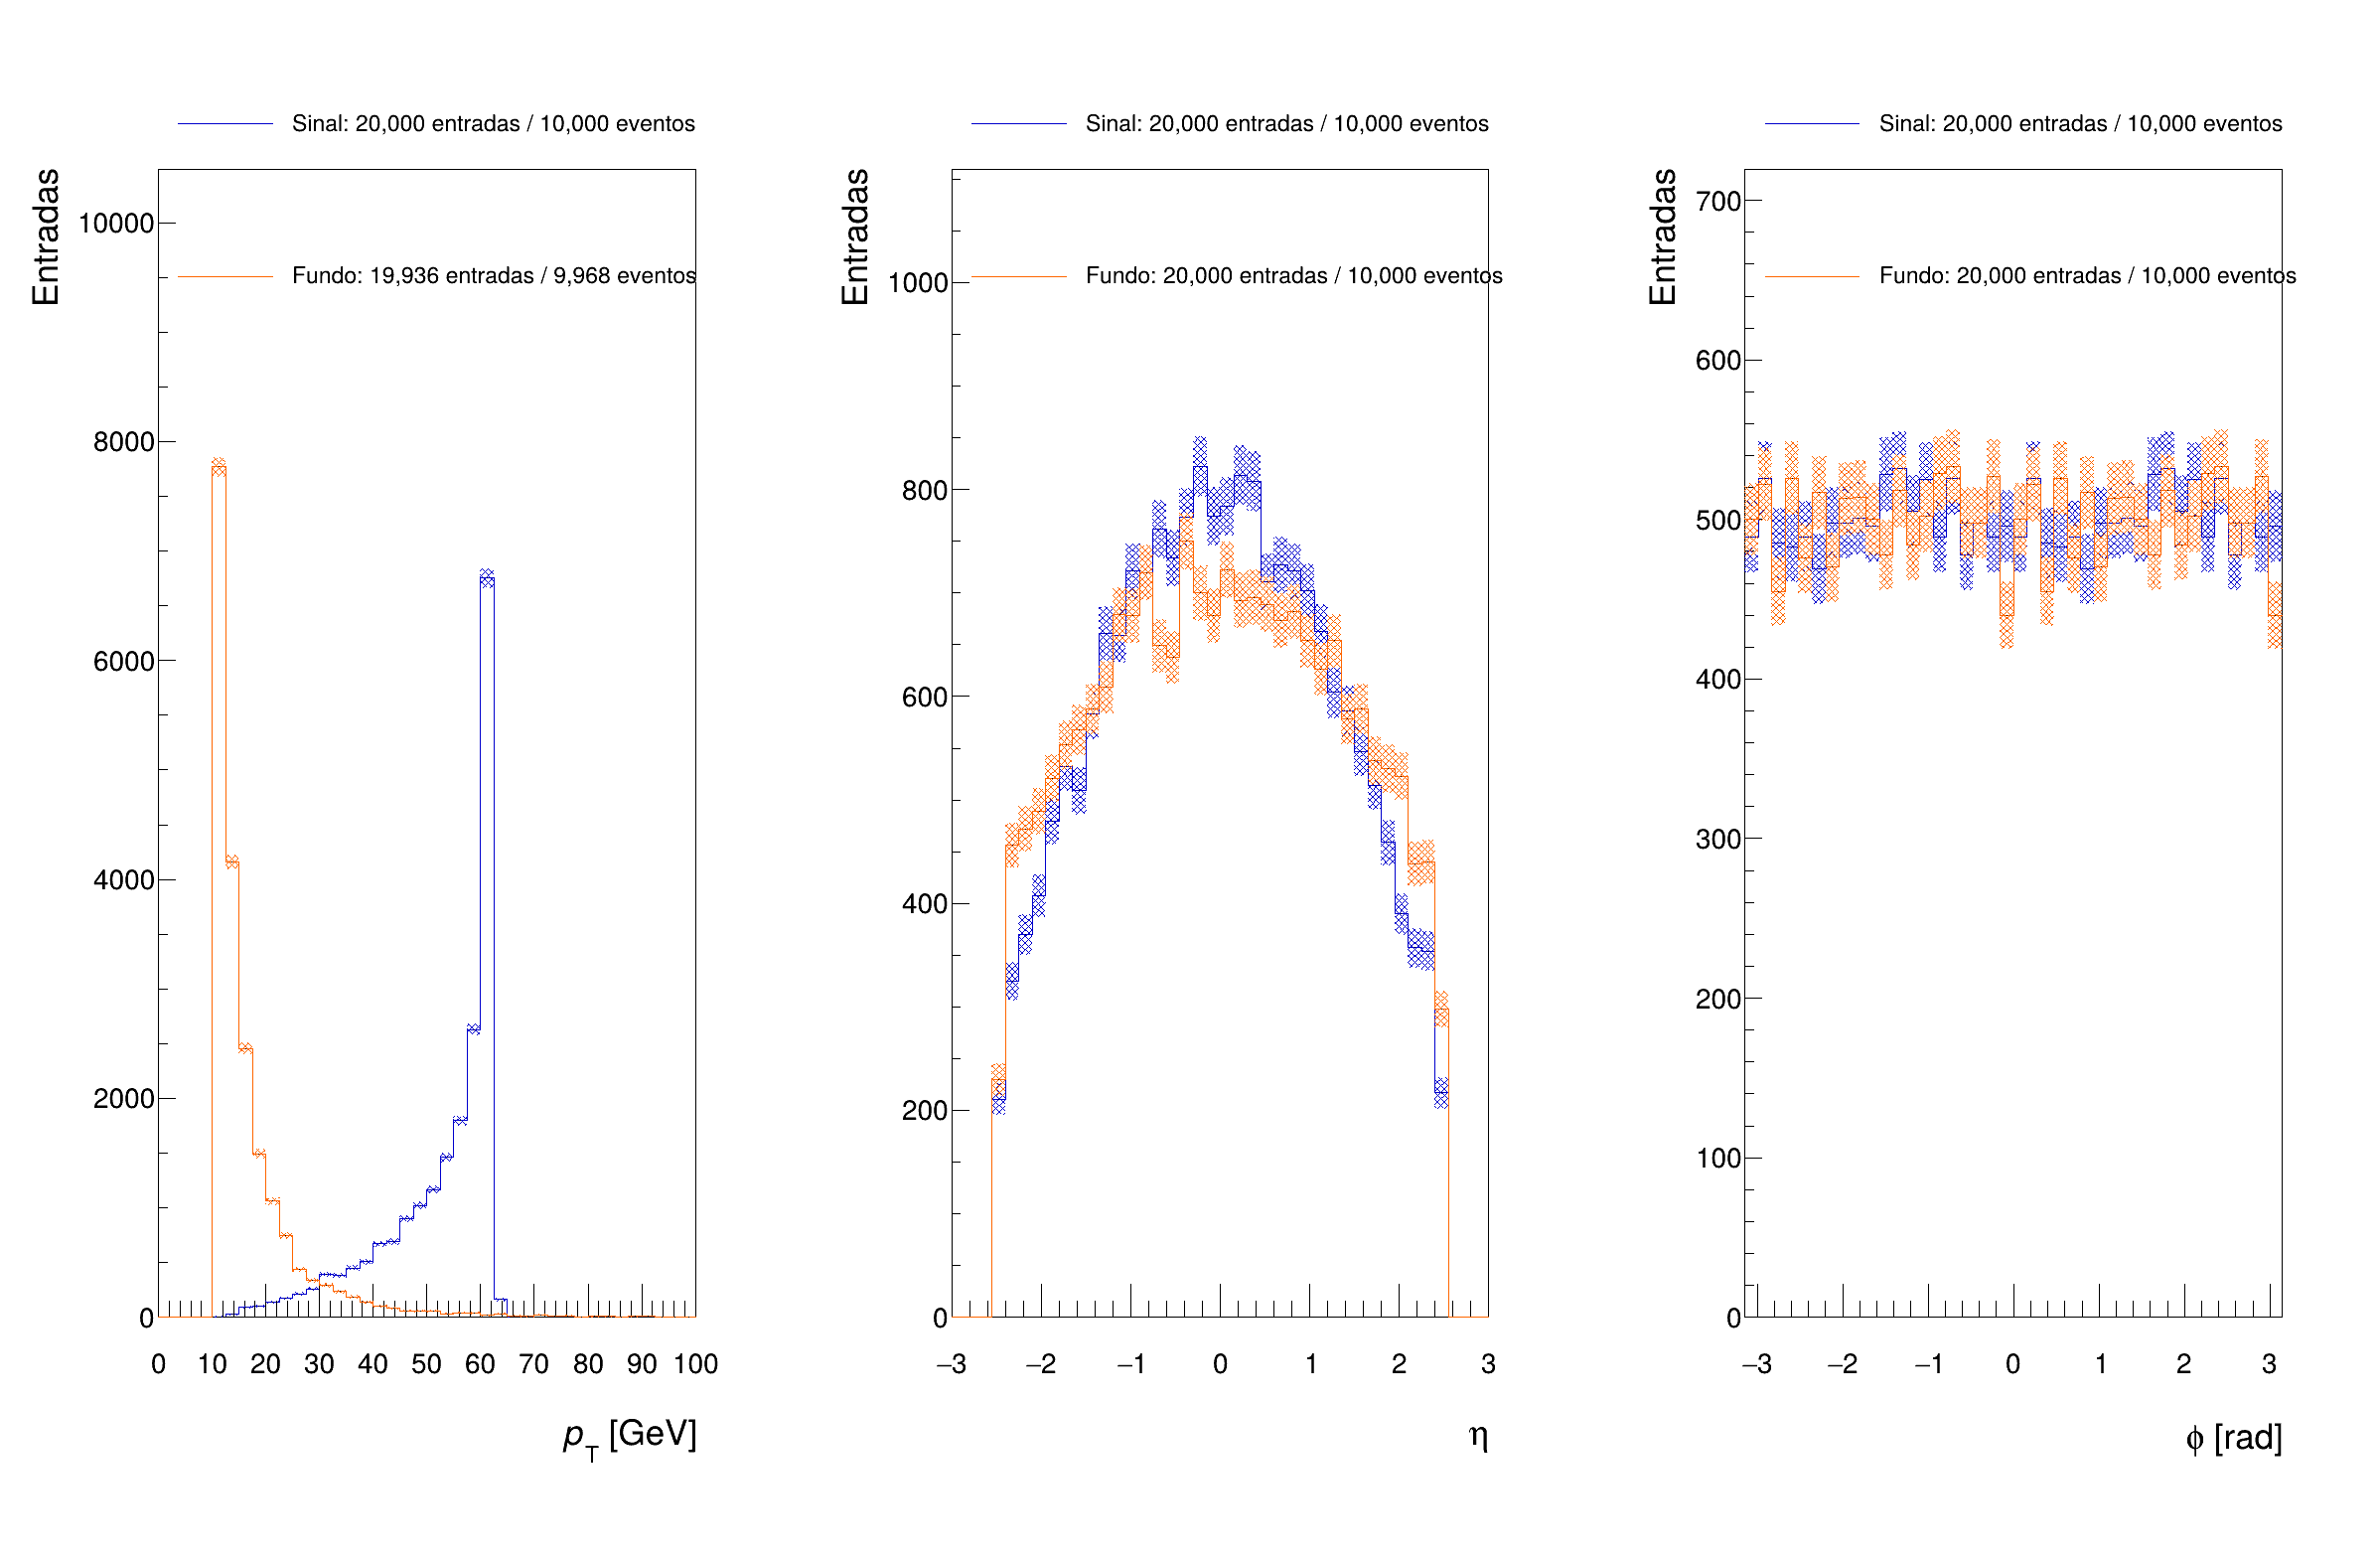

In [13]:
from IPython.display import Image, display

def exibir_png(caminho):
    """Incorpora o PNG gerado pelo ROOT no notebook."""
    display(Image(filename=str(caminho), width=1000))


for caminho_png in sorted(PASTA_GRAFICOS.glob("*_antes_cortes.png")):
    exibir_png(caminho_png)


### Objetivo desta célula

Calcula a cobertura dos histogramas em relação ao total de eventos gerados. O resultado revela se algum evento ficou fora dos intervalos escolhidos.


In [14]:
contagens_antes["Cobertura dos eventos (%)"] = (
    100 * contagens_antes["Eventos representados"] / contagens_antes["Eventos da amostra"]
)
display(contagens_antes.style.format({"Cobertura dos eventos (%)": "{:.2f}"}))

,Partícula,PDG ID,Variável,Amostra,Entradas totais,Underflow,Entradas no intervalo,Overflow,Eventos representados,Eventos da amostra,Cobertura dos eventos (%)
0,γ,22,pT [GeV],Sinal,20000,0,20000,0,10000,10000,100.00
1,γ,22,pT [GeV],Fundo,20000,0,19936,64,9968,10000,99.68
2,γ,22,eta,Sinal,20000,0,20000,0,10000,10000,100.00
3,γ,22,eta,Fundo,20000,0,20000,0,10000,10000,100.00
4,γ,22,phi,Sinal,20000,0,20000,0,10000,10000,100.00
5,γ,22,phi,Fundo,20000,0,20000,0,10000,10000,100.00


### Os histogramas representam todos os eventos?

Não necessariamente. Há quatro motivos possíveis:

1. uma espécie de partícula pode não aparecer em todos os eventos;
2. um evento pode conter mais de uma partícula da mesma espécie, produzindo mais entradas do que eventos;
3. neutrinos e partículas com `status != 1` foram removidos por definição;
4. uma partícula pode existir no evento, mas ficar fora do intervalo fixado para o histograma — especialmente $p_T>100$ GeV ou $|\eta|>3$.

Por isso, a tabela acima apresenta separadamente o número de **entradas** e o número de **eventos representados** em cada intervalo.

### Objetivo desta célula

Lista os eventos que não foram representados integralmente nos histogramas. O resultado orienta a investigação de perdas por limites de pT, eta ou phi.


In [15]:
cobertura_incompleta = contagens_antes[contagens_antes["Eventos representados"] < contagens_antes["Eventos da amostra"]]
if cobertura_incompleta.empty:
    print("Todos os eventos estão representados em todos os histogramas.")
else:
    print("Casos em que o intervalo do histograma não representa todos os eventos:")
    display(cobertura_incompleta[[
        "Partícula", "Variável", "Amostra",
        "Eventos representados", "Eventos da amostra",
    ]])

Casos em que o intervalo do histograma não representa todos os eventos:


,Partícula,Variável,Amostra,Eventos representados,Eventos da amostra
1,γ,pT [GeV],Fundo,9968,10000


### Variáveis em nível de evento

Uma análise do LHC também organiza os objetos dentro de cada evento. A seguir distinguimos os fótons líder e sublíder em $p_T$ e calculamos $\Delta\eta$, $\Delta\phi$ e $\Delta R=\sqrt{(\Delta\eta)^2+(\Delta\phi)^2}$ para o par de fótons.

### Objetivo desta célula

Define funções angulares e calcula as variáveis do par de fótons ordenado por pT. O resultado fornece pT líder/sublíder, separações angulares e Delta R por evento.


In [16]:
def delta_phi(phi_1, phi_2):
    return (phi_1 - phi_2 + math.pi) % (2 * math.pi) - math.pi

def variaveis_do_par(particulas, rotulo):
    colunas = {
        f"pT {rotulo} líder [GeV]": np.nan,
        f"pT {rotulo} sublíder [GeV]": np.nan,
        f"Maior |eta| {rotulo}": np.nan,
        f"Delta eta {rotulo}{rotulo}": np.nan,
        f"Delta phi {rotulo}{rotulo}": np.nan,
        f"Delta R {rotulo}{rotulo}": np.nan,
    }
    if len(particulas) != 2:
        return colunas
    lider, sublider = sorted(particulas, key=lambda p: p.pt, reverse=True)
    d_eta = lider.eta - sublider.eta
    d_phi = delta_phi(lider.phi, sublider.phi)
    colunas.update({
        f"pT {rotulo} líder [GeV]": lider.pt,
        f"pT {rotulo} sublíder [GeV]": sublider.pt,
        f"Maior |eta| {rotulo}": max(abs(lider.eta), abs(sublider.eta)),
        f"Delta eta {rotulo}{rotulo}": abs(d_eta),
        f"Delta phi {rotulo}{rotulo}": abs(d_phi),
        f"Delta R {rotulo}{rotulo}": math.hypot(d_eta, d_phi),
    })
    return colunas

def criar_tabela_eventos(eventos_por_amostra):
    linhas = []
    for amostra, lista_eventos in eventos_por_amostra.items():
        for indice_evento, evento in enumerate(lista_eventos, start=1):
            finais = particulas_finais_visiveis(evento)
            fotons = [p for p in finais if abs(p.pdg_id) == 22]
            linha = {
                "Amostra": amostra, "Evento": indice_evento,
                "Multiplicidade visível": len(finais),
                "Número de fótons": len(fotons),
                "Topologia esperada": len(fotons) == 2,
            }
            linha.update(variaveis_do_par(fotons, "γ"))
            linhas.append(linha)
    return pd.DataFrame(linhas)

dados_eventos = criar_tabela_eventos(eventos)
display(dados_eventos.head())
display(dados_eventos.groupby("Amostra").median(numeric_only=True).round(3))

,Amostra,Evento,Multiplicidade visível,Número de fótons,Topologia esperada,pT γ líder [GeV],pT γ sublíder [GeV],Maior |eta| γ,Delta eta γγ,Delta phi γγ,Delta R γγ
0,Sinal,1,2,2,True,62.446107,62.446107,0.549570,0.083601,3.141593,3.142705
1,Sinal,2,2,2,True,51.667197,51.667197,1.736769,1.273511,3.141593,3.389902
2,Sinal,3,2,2,True,49.629992,49.629992,0.906226,1.410884,3.141593,3.443864
3,Sinal,4,2,2,True,53.818517,53.818517,1.760828,1.121124,3.141593,3.335644
4,Sinal,5,2,2,True,41.636410,41.636410,1.990913,1.926374,3.141593,3.685176


,Evento,Multiplicidade visível,Número de fótons,Topologia esperada,pT γ líder [GeV],pT γ sublíder [GeV],Maior |eta| γ,Delta eta γγ,Delta phi γγ,Delta R γγ
Amostra,,,,,,,,,,
Fundo,5000.5,2.0,2.0,1.0,13.631,13.631,1.560,0.892,3.142,3.266
Sinal,5000.5,2.0,2.0,1.0,56.943,56.943,1.435,0.877,3.142,3.262


### Objetivo desta célula

Produz histogramas das variáveis do par de fótons para sinal e fundo. O resultado permite comparar diretamente a cinemática dos candidatos γγ.


In [17]:
VARIAVEIS_EVENTO = {
    "pT γ líder [GeV]": (0, 150),
    "pT γ sublíder [GeV]": (0, 150),
    "Maior |eta| γ": (0, 3),
    "Delta eta γγ": (0, 6),
    "Delta phi γγ": (0, math.pi),
    "Delta R γγ": (0, 6),
}
ROTULOS_EVENTO = {
    "pT γ líder [GeV]": "#it{p}_{T} #gamma_{lider} [GeV]",
    "pT γ sublíder [GeV]": "#it{p}_{T} #gamma_{sublider} [GeV]",
    "Maior |eta| γ": "Maior |#eta| #gamma",
    "Delta eta γγ": "#Delta #eta #gamma#gamma",
    "Delta phi γγ": "#Delta #phi #gamma#gamma",
    "Delta R γγ": "#Delta R #gamma#gamma",
}
fig, eixos = plt.subplots(2, 3, figsize=(16, 8))
for eixo, (variavel, intervalo) in zip(eixos.flat, VARIAVEIS_EVENTO.items()):
    for amostra in ("Sinal", "Fundo"):
        valores = dados_eventos.loc[dados_eventos["Amostra"] == amostra, variavel].dropna()
        contagens, bordas = np.histogram(valores, bins=40, range=intervalo)
        centros = (bordas[:-1] + bordas[1:]) / 2
        eixo.stairs(contagens, bordas, color=CORES[amostra], linewidth=1.7, label=amostra)
        eixo.errorbar(centros, contagens, yerr=np.sqrt(contagens), fmt="none", ecolor=CORES[amostra], alpha=0.6)
    eixo.set_xlabel(ROTULOS_EVENTO[variavel])
    eixo.set_ylabel("Eventos")
    eixo.legend()
fig.tight_layout()
fig.savefig(PASTA_GRAFICOS / "variaveis_evento_antes_cortes.png", dpi=150, bbox_inches="tight")
plt.show()


Warning in <TCanvas::Constructor>: Deleting canvas with same name: c


Info in <TCanvas::Print>: png file /private/var/folders/83/nqg6t5253dzbzhl2t658y2p80000gn/T/tmp.8IWRr49Oyc/resultados/graficos/variaveis_evento_antes_cortes.png has been created


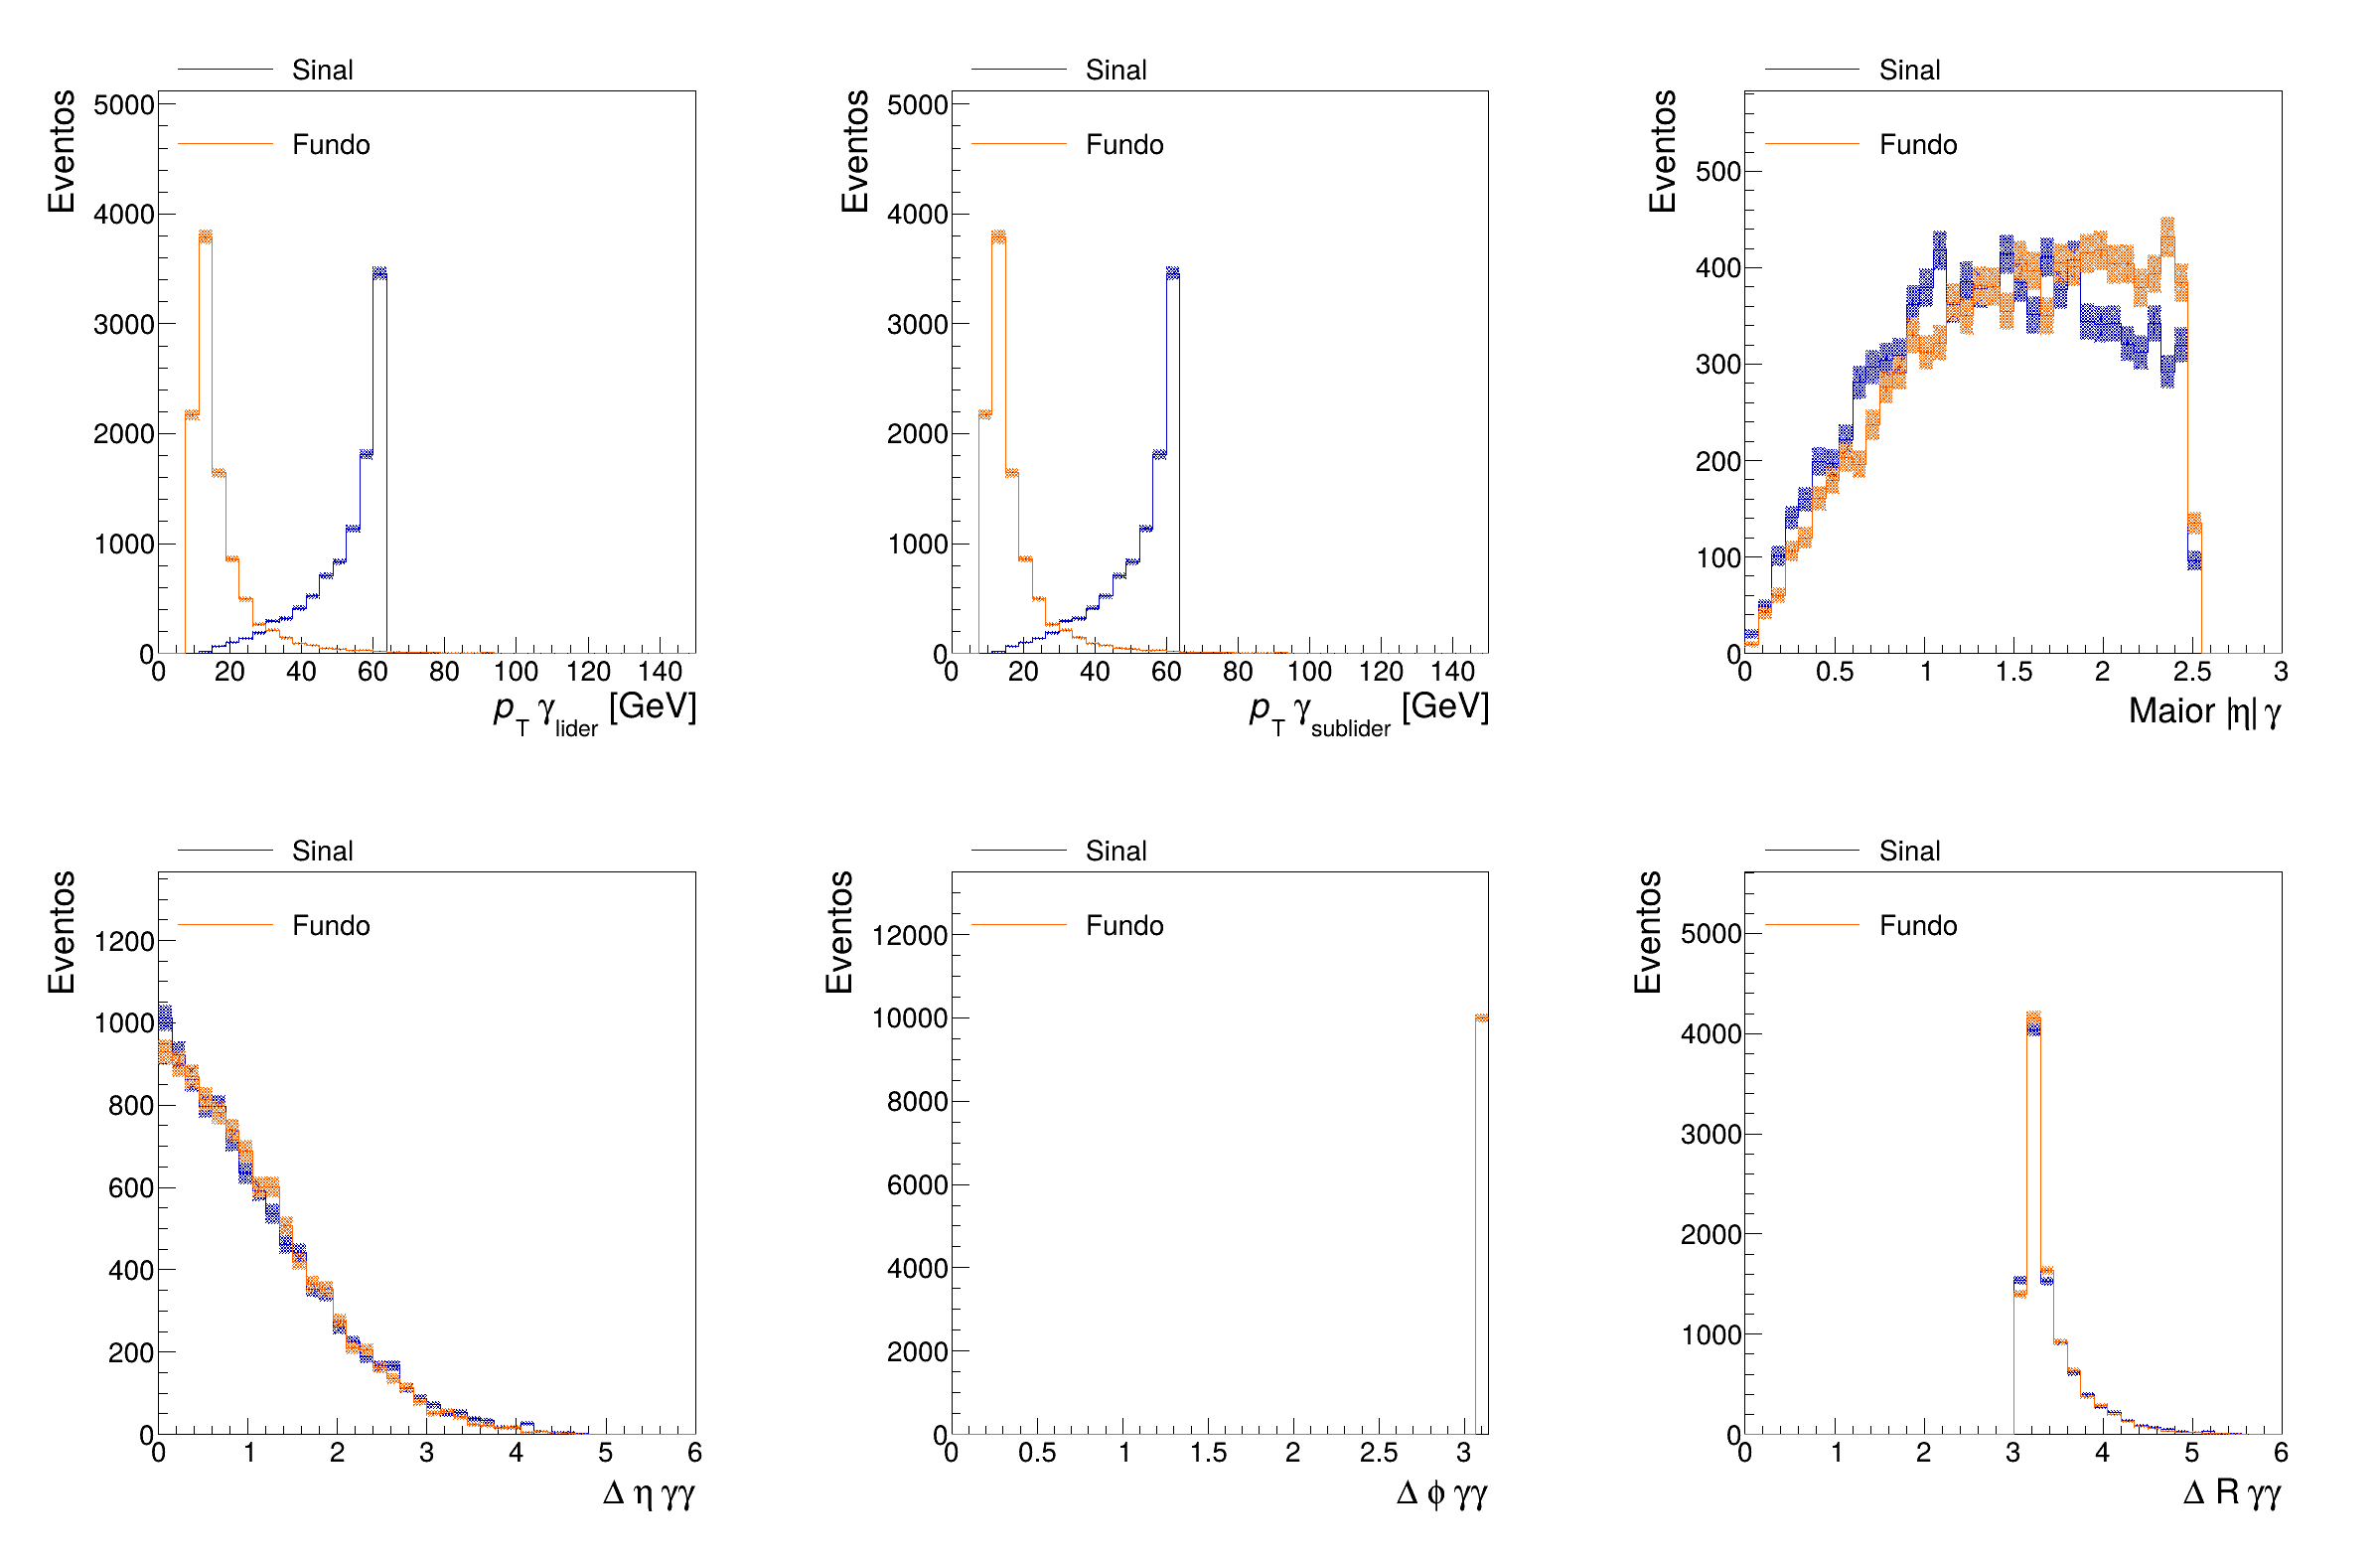

In [18]:
from IPython.display import Image, display

def exibir_png(caminho):
    """Incorpora o PNG gerado pelo ROOT no notebook."""
    display(Image(filename=str(caminho), width=1000))


exibir_png(PASTA_GRAFICOS / "variaveis_evento_antes_cortes.png")


## 4. Seleção cinemática e cutflow

Aplicaremos cortes aos fótons finais. Neste exemplo didático, exigimos $p_T>25$ GeV para o fóton sublíder, $|\eta|<2{,}5$ para ambos e $\Delta R>0{,}4$ entre eles. Esses valores são ilustrativos e não substituem uma seleção completa do CMS ou ATLAS.

A tabela de cutflow mostrará as eficiências incrementais e acumuladas. A razão $\epsilon_S/\epsilon_B$ mede apenas o ganho relativo da seleção; ela **não é uma significância estatística**.

Os cortes imitam a decisão analítica de manter candidatos compatíveis com o sinal e rejeitar eventos de fundo. O cutflow registra a fração que sobrevive em cada passo, $N_i/N_{i-1}$, permitindo identificar qual requisito é mais restritivo.


### Objetivo desta célula

Aplica os cortes de seleção da Parte 1 em topologia, aceitação e separação angular. O resultado é o cutflow com eventos restantes e eficiências incrementais/acumuladas.


In [19]:
PT_GAMMA = 25.0
ETA_GAMMA = 2.5
DELTA_R_MINIMO = 0.4

ETAPAS = [
    ("Sem cortes", lambda df: pd.Series(True, index=df.index)),
    ("Topologia: 2 fótons", lambda df: df["Topologia esperada"]),
    ("Aceitação dos fótons", lambda df: (df["pT γ sublíder [GeV]"] > PT_GAMMA) & (df["Maior |eta| γ"] < ETA_GAMMA)),
    ("Separação angular do par γγ", lambda df: df["Delta R γγ"] > DELTA_R_MINIMO),
]

mascaras_acumuladas = {
    amostra: pd.Series(True, index=dados_eventos.index[dados_eventos["Amostra"] == amostra])
    for amostra in ("Sinal", "Fundo")
}
anteriores = {amostra: int(mascara.sum()) for amostra, mascara in mascaras_acumuladas.items()}
iniciais = anteriores.copy()
linhas_cutflow = []

for ordem, (nome_etapa, construir_mascara) in enumerate(ETAPAS):
    linha = {"Ordem": ordem, "Etapa": nome_etapa}
    for amostra in ("Sinal", "Fundo"):
        dados_amostra = dados_eventos[dados_eventos["Amostra"] == amostra]
        mascaras_acumuladas[amostra] &= construir_mascara(dados_amostra)
        restantes = int(mascaras_acumuladas[amostra].sum())
        linha[f"Eventos {amostra.lower()}"] = restantes
        linha[f"Eficiência incremental {amostra.lower()} (%)"] = 100 * restantes / anteriores[amostra] if anteriores[amostra] else 0
        linha[f"Eficiência acumulada {amostra.lower()} (%)"] = 100 * restantes / iniciais[amostra]
        anteriores[amostra] = restantes
    ef_s = linha["Eficiência acumulada sinal (%)"]
    ef_b = linha["Eficiência acumulada fundo (%)"]
    linha["Ganho relativo εS/εB"] = ef_s / ef_b if ef_b else np.inf
    linhas_cutflow.append(linha)

cutflow = pd.DataFrame(linhas_cutflow).drop(columns="Ordem")
display(cutflow.style.format({coluna: "{:.2f}" for coluna in cutflow.columns if "Eficiência" in coluna or "Ganho" in coluna}))

eventos_aprovados = pd.concat([
    dados_eventos[dados_eventos["Amostra"] == amostra].loc[mascaras_acumuladas[amostra], ["Amostra", "Evento"]]
    for amostra in ("Sinal", "Fundo")
], ignore_index=True)

,Etapa,Eventos sinal,Eficiência incremental sinal (%),Eficiência acumulada sinal (%),Eventos fundo,Eficiência incremental fundo (%),Eficiência acumulada fundo (%),Ganho relativo εS/εB
0,Sem cortes,10000,100.00,100.00,10000,100.00,100.00,1.00
1,Topologia: 2 fótons,10000,100.00,100.00,10000,100.00,100.00,1.00
2,Aceitação dos fótons,9732,97.32,97.32,1156,11.56,11.56,8.42
3,Separação angular do par γγ,9732,100.00,97.32,1156,100.00,11.56,8.42


### Objetivo desta célula

Cruza a seleção com a tabela de partículas e constrói a amostra após os cortes. O resultado mostra quais entradas cinemáticas pertencem aos eventos aprovados.


In [20]:
dados_apos_corte = dados_cinematicos.merge(
    eventos_aprovados, on=["Amostra", "Evento"], how="inner"
)
contagens_depois = plotar_comparacao(
    dados_apos_corte, titulo_extra=" após o cutflow completo",
    sufixo_arquivo="apos_cutflow",
)
display(contagens_depois)

Warning in <TCanvas::Constructor>: Deleting canvas with same name: c


Info in <TCanvas::Print>: png file /private/var/folders/83/nqg6t5253dzbzhl2t658y2p80000gn/T/tmp.8IWRr49Oyc/resultados/graficos/pdg_22_apos_cutflow.png has been created


,Partícula,PDG ID,Variável,Amostra,Entradas totais,Underflow,Entradas no intervalo,Overflow,Eventos representados,Eventos da amostra
0,γ,22,pT [GeV],Sinal,19464,0,19464,0,9732,10000
1,γ,22,pT [GeV],Fundo,2312,0,2248,64,1124,10000
2,γ,22,eta,Sinal,19464,0,19464,0,9732,10000
3,γ,22,eta,Fundo,2312,0,2312,0,1156,10000
4,γ,22,phi,Sinal,19464,0,19464,0,9732,10000
5,γ,22,phi,Fundo,2312,0,2312,0,1156,10000


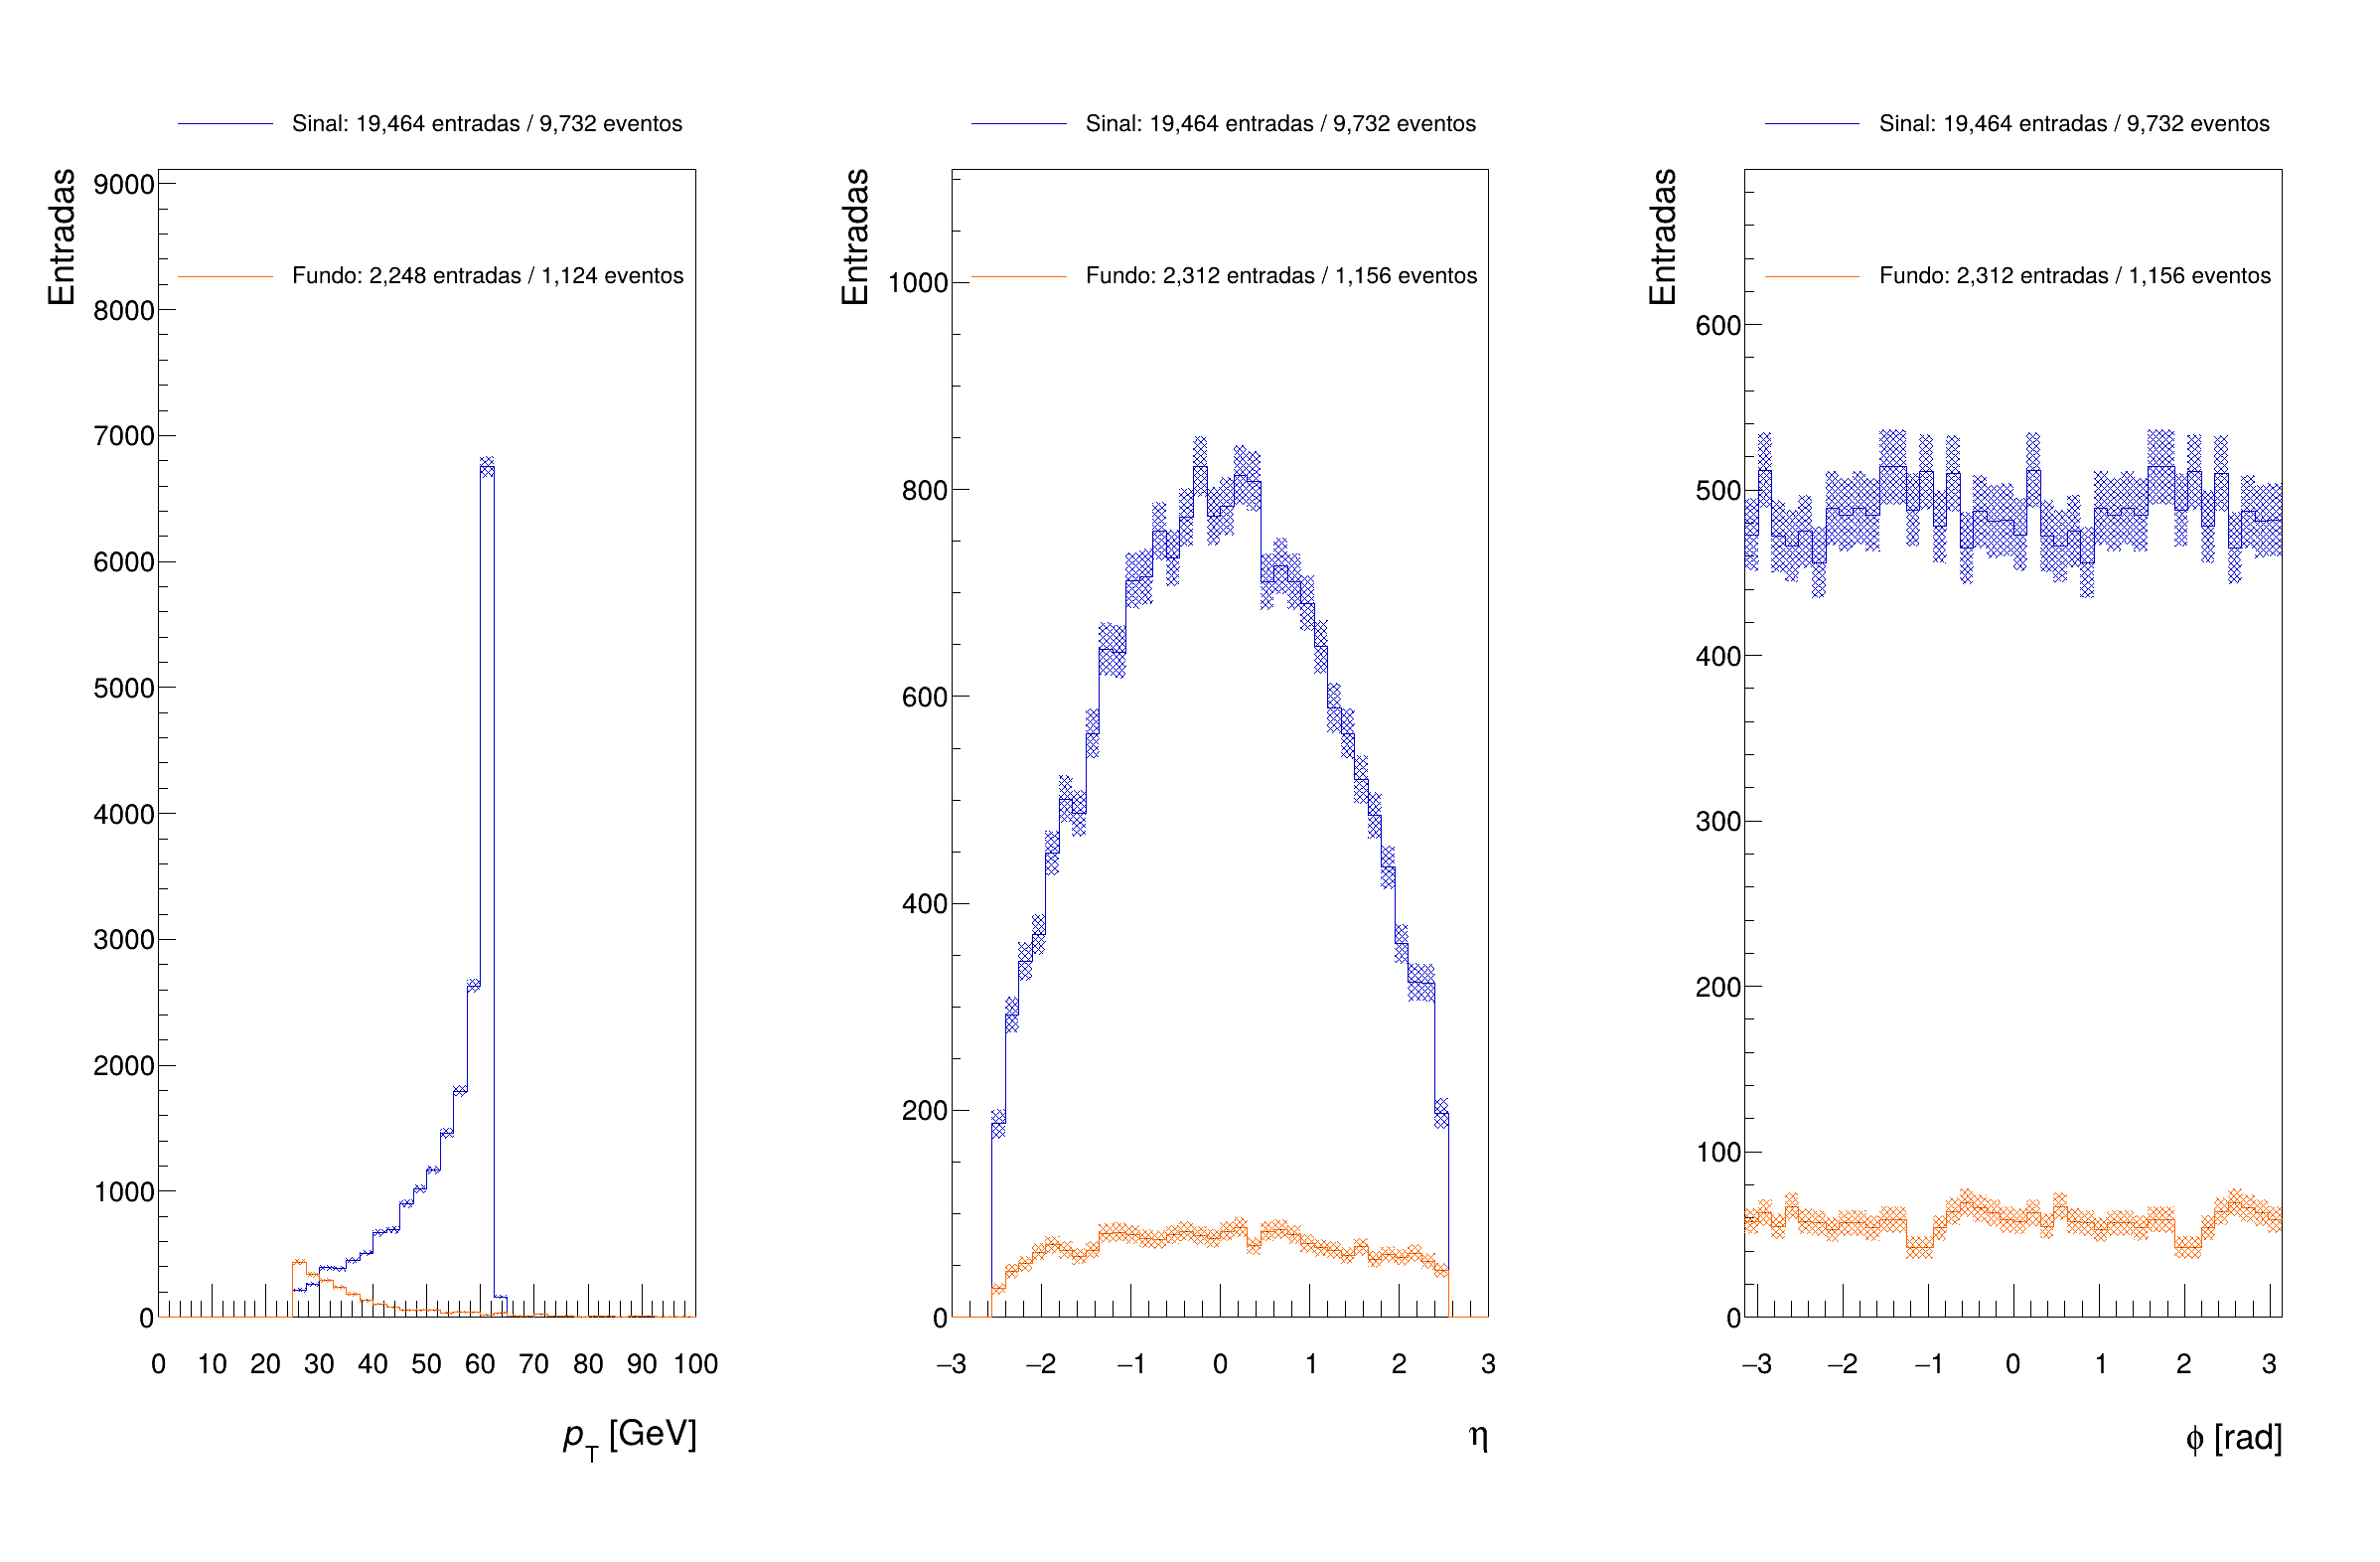

In [21]:
from IPython.display import Image, display

def exibir_png(caminho):
    """Incorpora o PNG gerado pelo ROOT no notebook."""
    display(Image(filename=str(caminho), width=1000))


for caminho_png in sorted(PASTA_GRAFICOS.glob("*_apos_cutflow.png")):
    exibir_png(caminho_png)


## 5. Conclusões da Parte 1

- As duas amostras possuem o mesmo estado final em nível de gerador: dois fótons.
- A amostra de sinal contém um bóson de Higgs que decai em dois fótons; o fundo produz o mesmo estado final sem exigir um Higgs intermediário.
- A massa invariante do par de fótons é a variável central para visualizar a assinatura do Higgs.
- O cutflow permite identificar qual requisito rejeita mais fundo e qual é o custo acumulado em eficiência do sinal.
- Os resultados são de nível de gerador. Uma análise experimental exigiria reconstrução, eficiência, resolução, trigger e demais efeitos do detector.
- A normalização por seção de choque e luminosidade, assim como $S/B$ e $S/\sqrt{B}$, pertence à Parte 2.

Agora reunimos as evidências da leitura, da identificação física e da seleção. A síntese deve distinguir claramente quantidades observadas diretamente no LHE de efeitos introduzidos pela eficiência e pelos cortes, preparando a normalização da Parte 2.


### Objetivo desta célula

Extrai a última etapa do cutflow para preparar a conclusão da Parte 1. O resultado registra os eventos e a eficiência final de sinal e fundo.


In [22]:
ultima_etapa = cutflow.iloc[-1]
ef_sinal = ultima_etapa["Eficiência acumulada sinal (%)"]
ef_fundo = ultima_etapa["Eficiência acumulada fundo (%)"]
ganho = ef_sinal / ef_fundo if ef_fundo else np.inf
rejeicoes = cutflow.iloc[1:].copy()
rejeicoes["Rejeição incremental do fundo (%)"] = 100 - rejeicoes["Eficiência incremental fundo (%)"]
etapa_mais_forte = rejeicoes.loc[rejeicoes["Rejeição incremental do fundo (%)"].idxmax()]
display(Markdown(
    f"**Resultado final do cutflow:** eficiência acumulada de {ef_sinal:.1f}% para o sinal "
    f"e {ef_fundo:.1f}% para o fundo. O ganho relativo $\\epsilon_S/\\epsilon_B$ é {ganho:.1f}. "
    f"A etapa que mais rejeitou fundo incrementalmente foi **{etapa_mais_forte['Etapa']}**. "
    "Esse ganho não deve ser interpretado como significância estatística."
))
print(f"Gráficos salvos em: {PASTA_GRAFICOS}")

**Resultado final do cutflow:** eficiência acumulada de 97.3% para o sinal e 11.6% para o fundo. O ganho relativo $\epsilon_S/\epsilon_B$ é 8.4. A etapa que mais rejeitou fundo incrementalmente foi **Aceitação dos fótons**. Esse ganho não deve ser interpretado como significância estatística.

Gráficos salvos em: /private/var/folders/83/nqg6t5253dzbzhl2t658y2p80000gn/T/tmp.8IWRr49Oyc/resultados/graficos


## Respostas de referência verificadas nas amostras

Estas amostras representam `pp → H → γγ` (sinal) e o contínuo `pp → γγ` (fundo). A tabela de eventos deve mostrar dois fótons finais por evento, sem `NaN` nas variáveis do par. O sinal deve apresentar um pico próximo de 125 GeV na massa invariante $m_{γγ}$, enquanto o fundo forma uma distribuição contínua.

Os números exatos de eventos, eficiências, yields e significâncias devem ser obtidos executando as células; eles dependem dos cortes e da luminosidade definidos no notebook. A interpretação deve deixar claro que os eventos estão em nível de gerador e não incluem resolução ou reconstrução real do detector.

As respostas servem como uma verificação reproduzível, não como números isolados. Cada valor deve poder ser rastreado a uma contagem, a um corte ou a uma fórmula definida nas etapas anteriores.


# Parte 2 — conservação, massas e normalização

A seguir, a análise continua com as grandezas físicas e a normalização da Parte 2, mantendo a abordagem baseada em DataFrame.

Na Parte 2 passamos de partículas individuais para candidatos físicos e yields comparáveis. A relação $N=\sigma\,\mathcal{L}\,A\,\varepsilon$ será nossa guia: a seção de choque descreve a produção, a luminosidade a exposição e $A\varepsilon$ a fração que aceita e reconstrói o evento.


### Luminosidade adotada no início da Parte 2

Define a luminosidade integrada usada na normalização e na estimativa da seção de choque. As ferramentas e os arquivos LHE já foram preparados anteriormente.


In [23]:
LUMINOSIDADE_PB = 10000.0
print(f"Luminosidade adotada: {LUMINOSIDADE_PB:g} pb^-1")


Luminosidade adotada: 10000 pb^-1


## Emulação de eficiência detectora

Antes da normalização, associamos a cada partícula uma eficiência paramétrica dependente de $p_T$ e $|eta|$. Uma semente fixa torna a decisão aleatória reprodutível. Este modelo é apenas uma aproximação didática inspirada na forma de uma curva de resposta; não representa uma calibração oficial do CMS.

A eficiência $\varepsilon(p_T,\eta)$ modela a resposta detectora sem simular toda a eletrônica, associando uma probabilidade a cada partícula.


In [24]:
def eficiencia_parametrica(pdg_id, pt, eta):
    """Modelo didático vetorizado de eficiência por espécie, pT e eta."""
    pdg = np.asarray(pdg_id, dtype=int)
    pt = np.asarray(pt, dtype=float)
    eta = np.asarray(eta, dtype=float)
    abs_pdg = np.abs(pdg)
    abs_eta = np.abs(eta)

    plateau = np.select(
        [np.isin(abs_pdg, [12, 14, 16]), abs_pdg == 22, abs_pdg == 13,
         np.isin(abs_pdg, [1, 2, 3, 4, 5, 6, 21])],
        [0.0, 0.90, 0.95, 0.80],
        default=0.70,
    )
    pt50 = np.select(
        [abs_pdg == 22, abs_pdg == 13, np.isin(abs_pdg, [1, 2, 3, 4, 5, 6, 21])],
        [24.0, 18.0, 22.0],
        default=20.0,
    )
    largura = np.select(
        [abs_pdg == 22, abs_pdg == 13, np.isin(abs_pdg, [1, 2, 3, 4, 5, 6, 21])],
        [4.0, 3.0, 5.0],
        default=5.0,
    )
    fator_eta = np.where(abs_eta < 1.5, 1.0, np.where(abs_eta < 2.5, 0.92, 0.0))
    turn_on = 0.5 * (1.0 + np.tanh((pt - pt50) / largura))
    return np.clip(plateau * fator_eta * turn_on, 0.0, 1.0)

particulas_df["eficiencia"] = eficiencia_parametrica(
    particulas_df["PDG ID"], particulas_df["pT [GeV]"], particulas_df["eta"]
)
rng_detector = np.random.default_rng(20260904)
particulas_df["reconstruida"] = rng_detector.random(len(particulas_df)) < particulas_df["eficiencia"]
eventos = converter_dataframes_para_eventos(eventos_df, particulas_df)
display(particulas_df[["Amostra", "Evento", "PDG ID", "pT [GeV]", "eta", "eficiencia", "reconstruida"]].head())


,Amostra,Evento,PDG ID,pT [GeV],eta,eficiencia,reconstruida
0,Sinal,1,21,0.000000,NaN,0.0,False
1,Sinal,1,21,0.000000,NaN,0.0,False
2,Sinal,1,25,0.000000,NaN,0.0,False
3,Sinal,1,22,62.446107,0.549570,0.9,True
4,Sinal,1,22,62.446107,0.465969,0.9,True


### Turn-on da eficiência em função de $p_T$

A curva mede a fração de partículas de referência reconstruídas em cada faixa de $p_T$, com incertezas binomiais. É uma aproximação didática de uma resposta de trigger/reconstrução, não uma calibração experimental.


In [25]:
referencia = particulas_df[
    (particulas_df["status"] == 1)
    & (particulas_df["PDG ID"].abs() == 22)
    & (particulas_df["eta"].abs() < 2.5)
].copy()
bordas_pt = np.linspace(0.0, 120.0, 25)
referencia["faixa_pt"] = pd.cut(referencia["pT [GeV]"], bins=bordas_pt, include_lowest=True)
turn_on = referencia.groupby("faixa_pt", observed=False)["reconstruida"].agg(["mean", "count"]).rename(columns={"mean": "eficiencia"})
turn_on["erro"] = np.sqrt(turn_on["eficiencia"] * (1.0 - turn_on["eficiencia"]) / turn_on["count"])
turn_on["pT central [GeV]"] = [intervalo.mid if hasattr(intervalo, "mid") else np.nan for intervalo in turn_on.index]
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.errorbar(turn_on["pT central [GeV]"], turn_on["eficiencia"], yerr=turn_on["erro"], fmt="o", color="tab:blue", capsize=3, label="Fotons")
ax.set_xlabel("#it{p}_{T} [GeV]")
ax.set_ylabel("Eficiencia de reconstrucao emulada")
# Limite acima da maior barra de erro, sem cortar a banda de incerteza.
limite_eficiencia = (turn_on["eficiencia"] + turn_on["erro"]).dropna().max()
ax.set_ylim(0.0, max(1.05, 1.10 * float(limite_eficiencia)))
ax.legend()
fig.tight_layout()
fig.savefig(PASTA_GRAFICOS / "parte2_turn_on_eficiencia.png", dpi=150, bbox_inches="tight")
plt.show()


Warning in <TCanvas::Constructor>: Deleting canvas with same name: c


Info in <TCanvas::Print>: png file /private/var/folders/83/nqg6t5253dzbzhl2t658y2p80000gn/T/tmp.8IWRr49Oyc/resultados/graficos/parte2_turn_on_eficiencia.png has been created


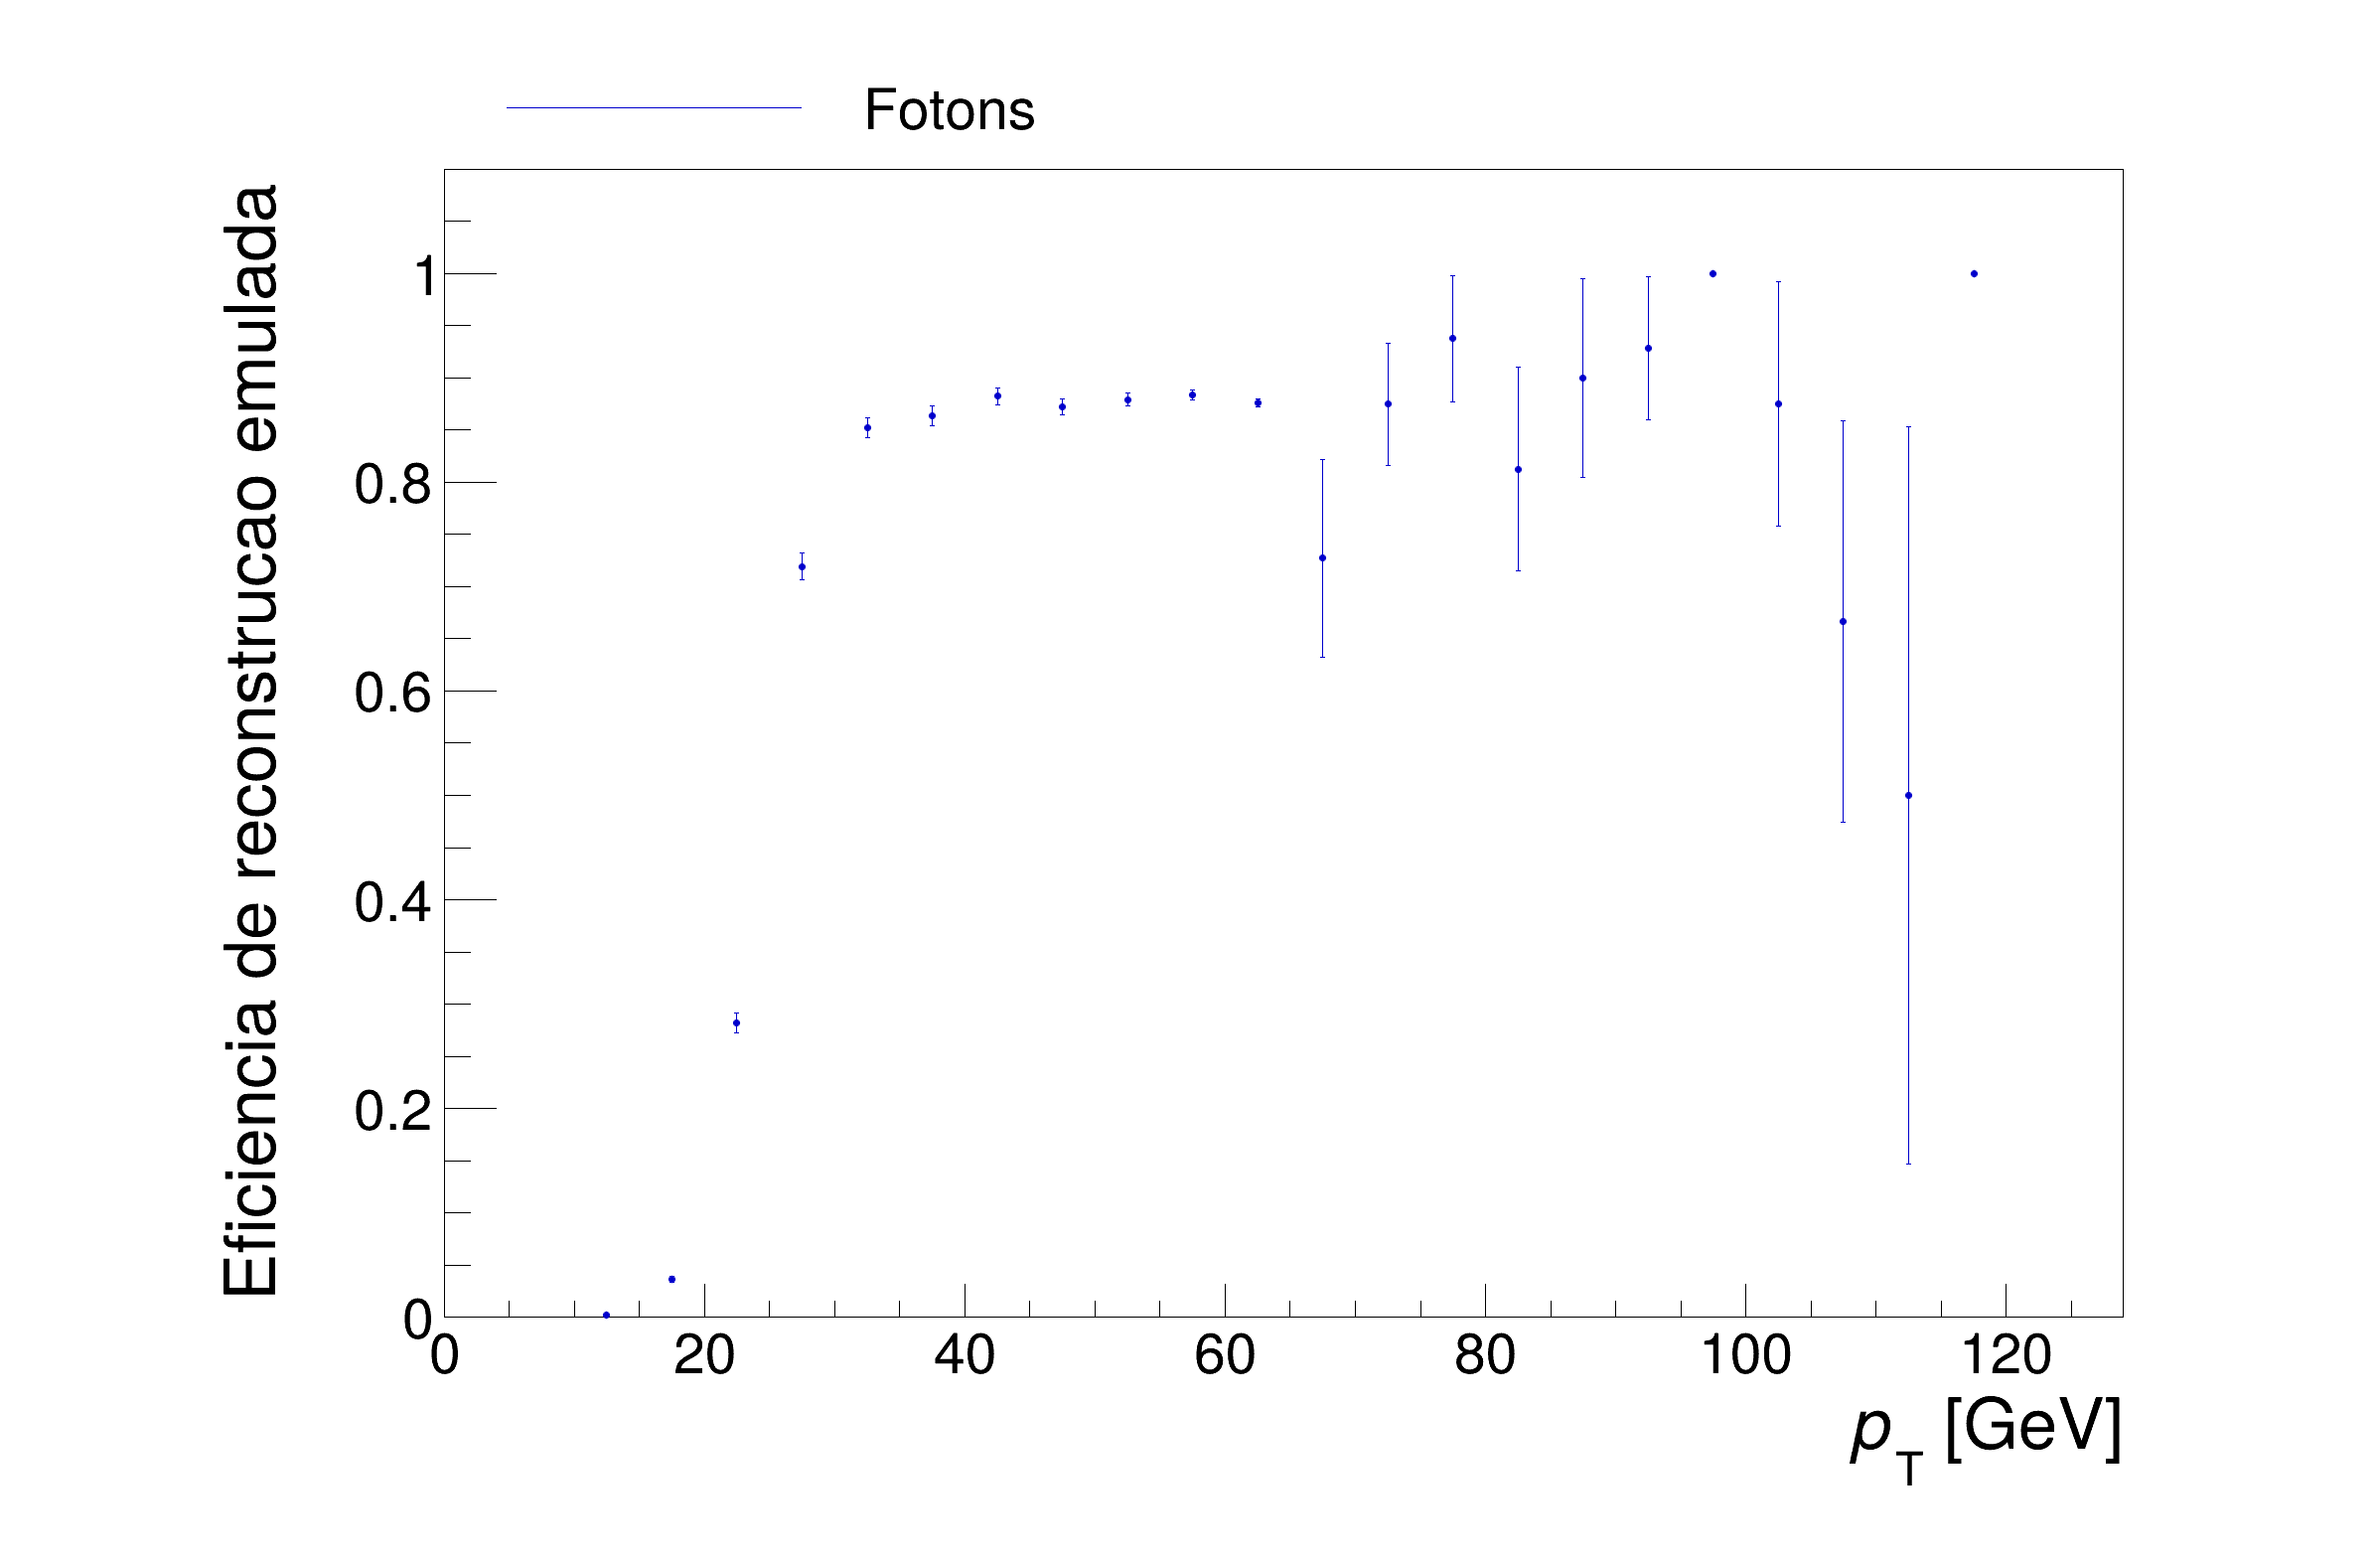

In [26]:
from IPython.display import Image, display

def exibir_png(caminho):
    """Incorpora o PNG gerado pelo ROOT no notebook."""
    display(Image(filename=str(caminho), width=1000))


exibir_png(PASTA_GRAFICOS / "parte2_turn_on_eficiencia.png")


## Comparação antes e depois da eficiência

Compare, separadamente para sinal e fundo, as distribuições de $p_T$, $\eta$ e $\phi$ antes e depois da reconstrução. Cada figura deve conter os histogramas no painel superior e a razão depois/antes no painel inferior.

Uma partícula produzida nem sempre é reconstruída. Usamos uma eficiência $\varepsilon(p_T,\eta)$ e sorteamos a reconstrução com $P(\mathrm{reconstruída})=\varepsilon$; comparar as distribuições antes e depois mostra, de forma controlada, como a resposta do detector altera os dados observados.


In [27]:
def plotar_antes_depois_eficiencia(particulas):
    configuracoes = {
        "pT [GeV]": ((0, 100), "#it{p}_{T} [GeV]"),
        "eta": ((-3, 3), "#eta"),
        "phi": ((-math.pi, math.pi), "#phi [rad]"),
    }
    base = particulas[(particulas["status"] == 1) & ~particulas["PDG ID"].abs().isin({12, 14, 16})]
    for amostra in ("Sinal", "Fundo"):
        fig, eixos = plt.subplots(2, 3, figsize=(16, 8))
        selecao = base[base["Amostra"] == amostra]
        for coluna, (intervalo, rotulo), eixo_cima, eixo_baixo in zip(
            configuracoes, configuracoes.values(), eixos[0], eixos[1]
        ):
            antes = selecao[coluna].dropna()
            depois = selecao.loc[selecao["reconstruida"], coluna].dropna()
            cont_antes, bordas = np.histogram(antes, bins=40, range=intervalo)
            cont_depois, _ = np.histogram(depois, bins=40, range=intervalo)
            eixo_cima.stairs(cont_antes, bordas, color="black", linewidth=1.8, label="Antes")
            eixo_cima.stairs(cont_depois, bordas, color="tab:blue", linewidth=1.8, label="Depois")
            eixo_cima.set_xlabel(rotulo)
            eixo_cima.set_ylabel("Entradas")
            eixo_cima.legend(fontsize=10)
            razao = np.divide(cont_depois, cont_antes, out=np.zeros_like(cont_depois, dtype=float), where=cont_antes > 0)
            eixo_baixo.stairs(razao, bordas, color="tab:green", linewidth=1.6, label="Depois/antes")
            eixo_baixo.set_xlabel(rotulo)
            eixo_baixo.set_ylabel("Depois/antes")
            eixo_baixo.set_ylim(0.0, 2.0)
        fig.savefig(PASTA_GRAFICOS / f"eficiencia_antes_depois_{amostra.lower()}.png", dpi=150, bbox_inches="tight")
        plt.show()

plotar_antes_depois_eficiencia(particulas_df)


Warning in <TCanvas::Constructor>: Deleting canvas with same name: c


Info in <TCanvas::Print>: png file /private/var/folders/83/nqg6t5253dzbzhl2t658y2p80000gn/T/tmp.8IWRr49Oyc/resultados/graficos/eficiencia_antes_depois_sinal.png has been created


Warning in <TCanvas::Constructor>: Deleting canvas with same name: c
Info in <TCanvas::Print>: png file /private/var/folders/83/nqg6t5253dzbzhl2t658y2p80000gn/T/tmp.8IWRr49Oyc/resultados/graficos/eficiencia_antes_depois_fundo.png has been created


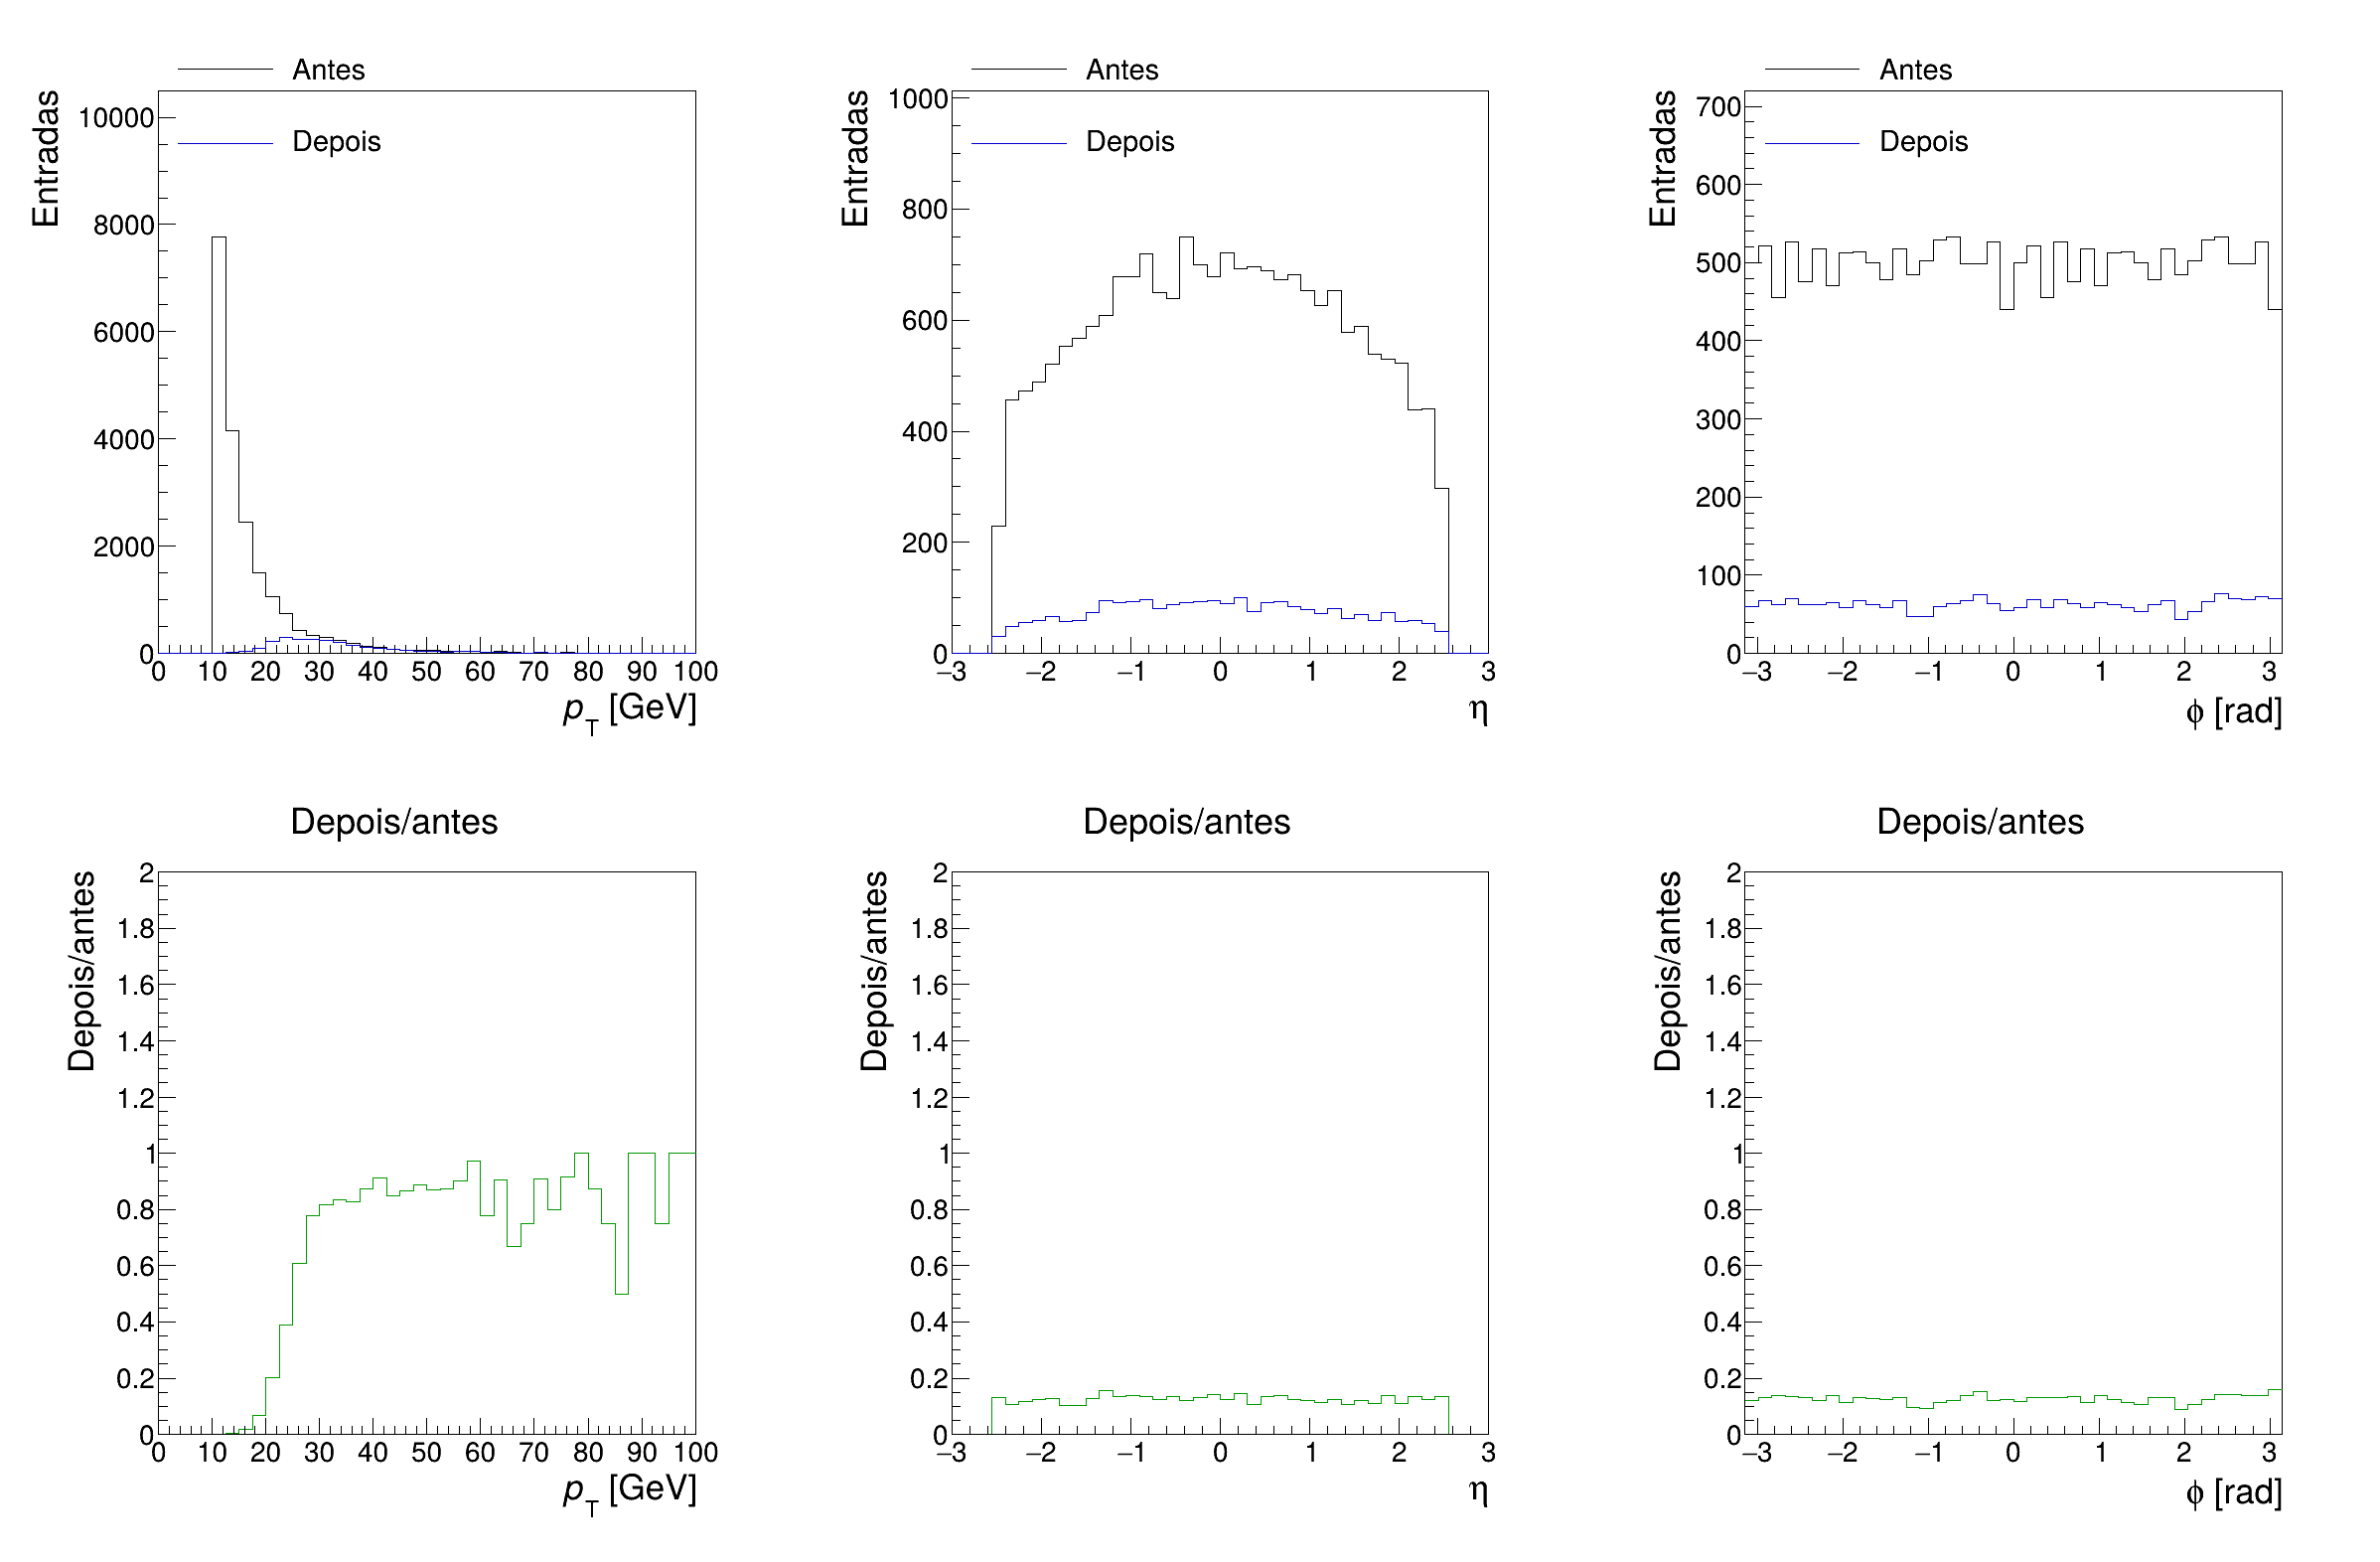

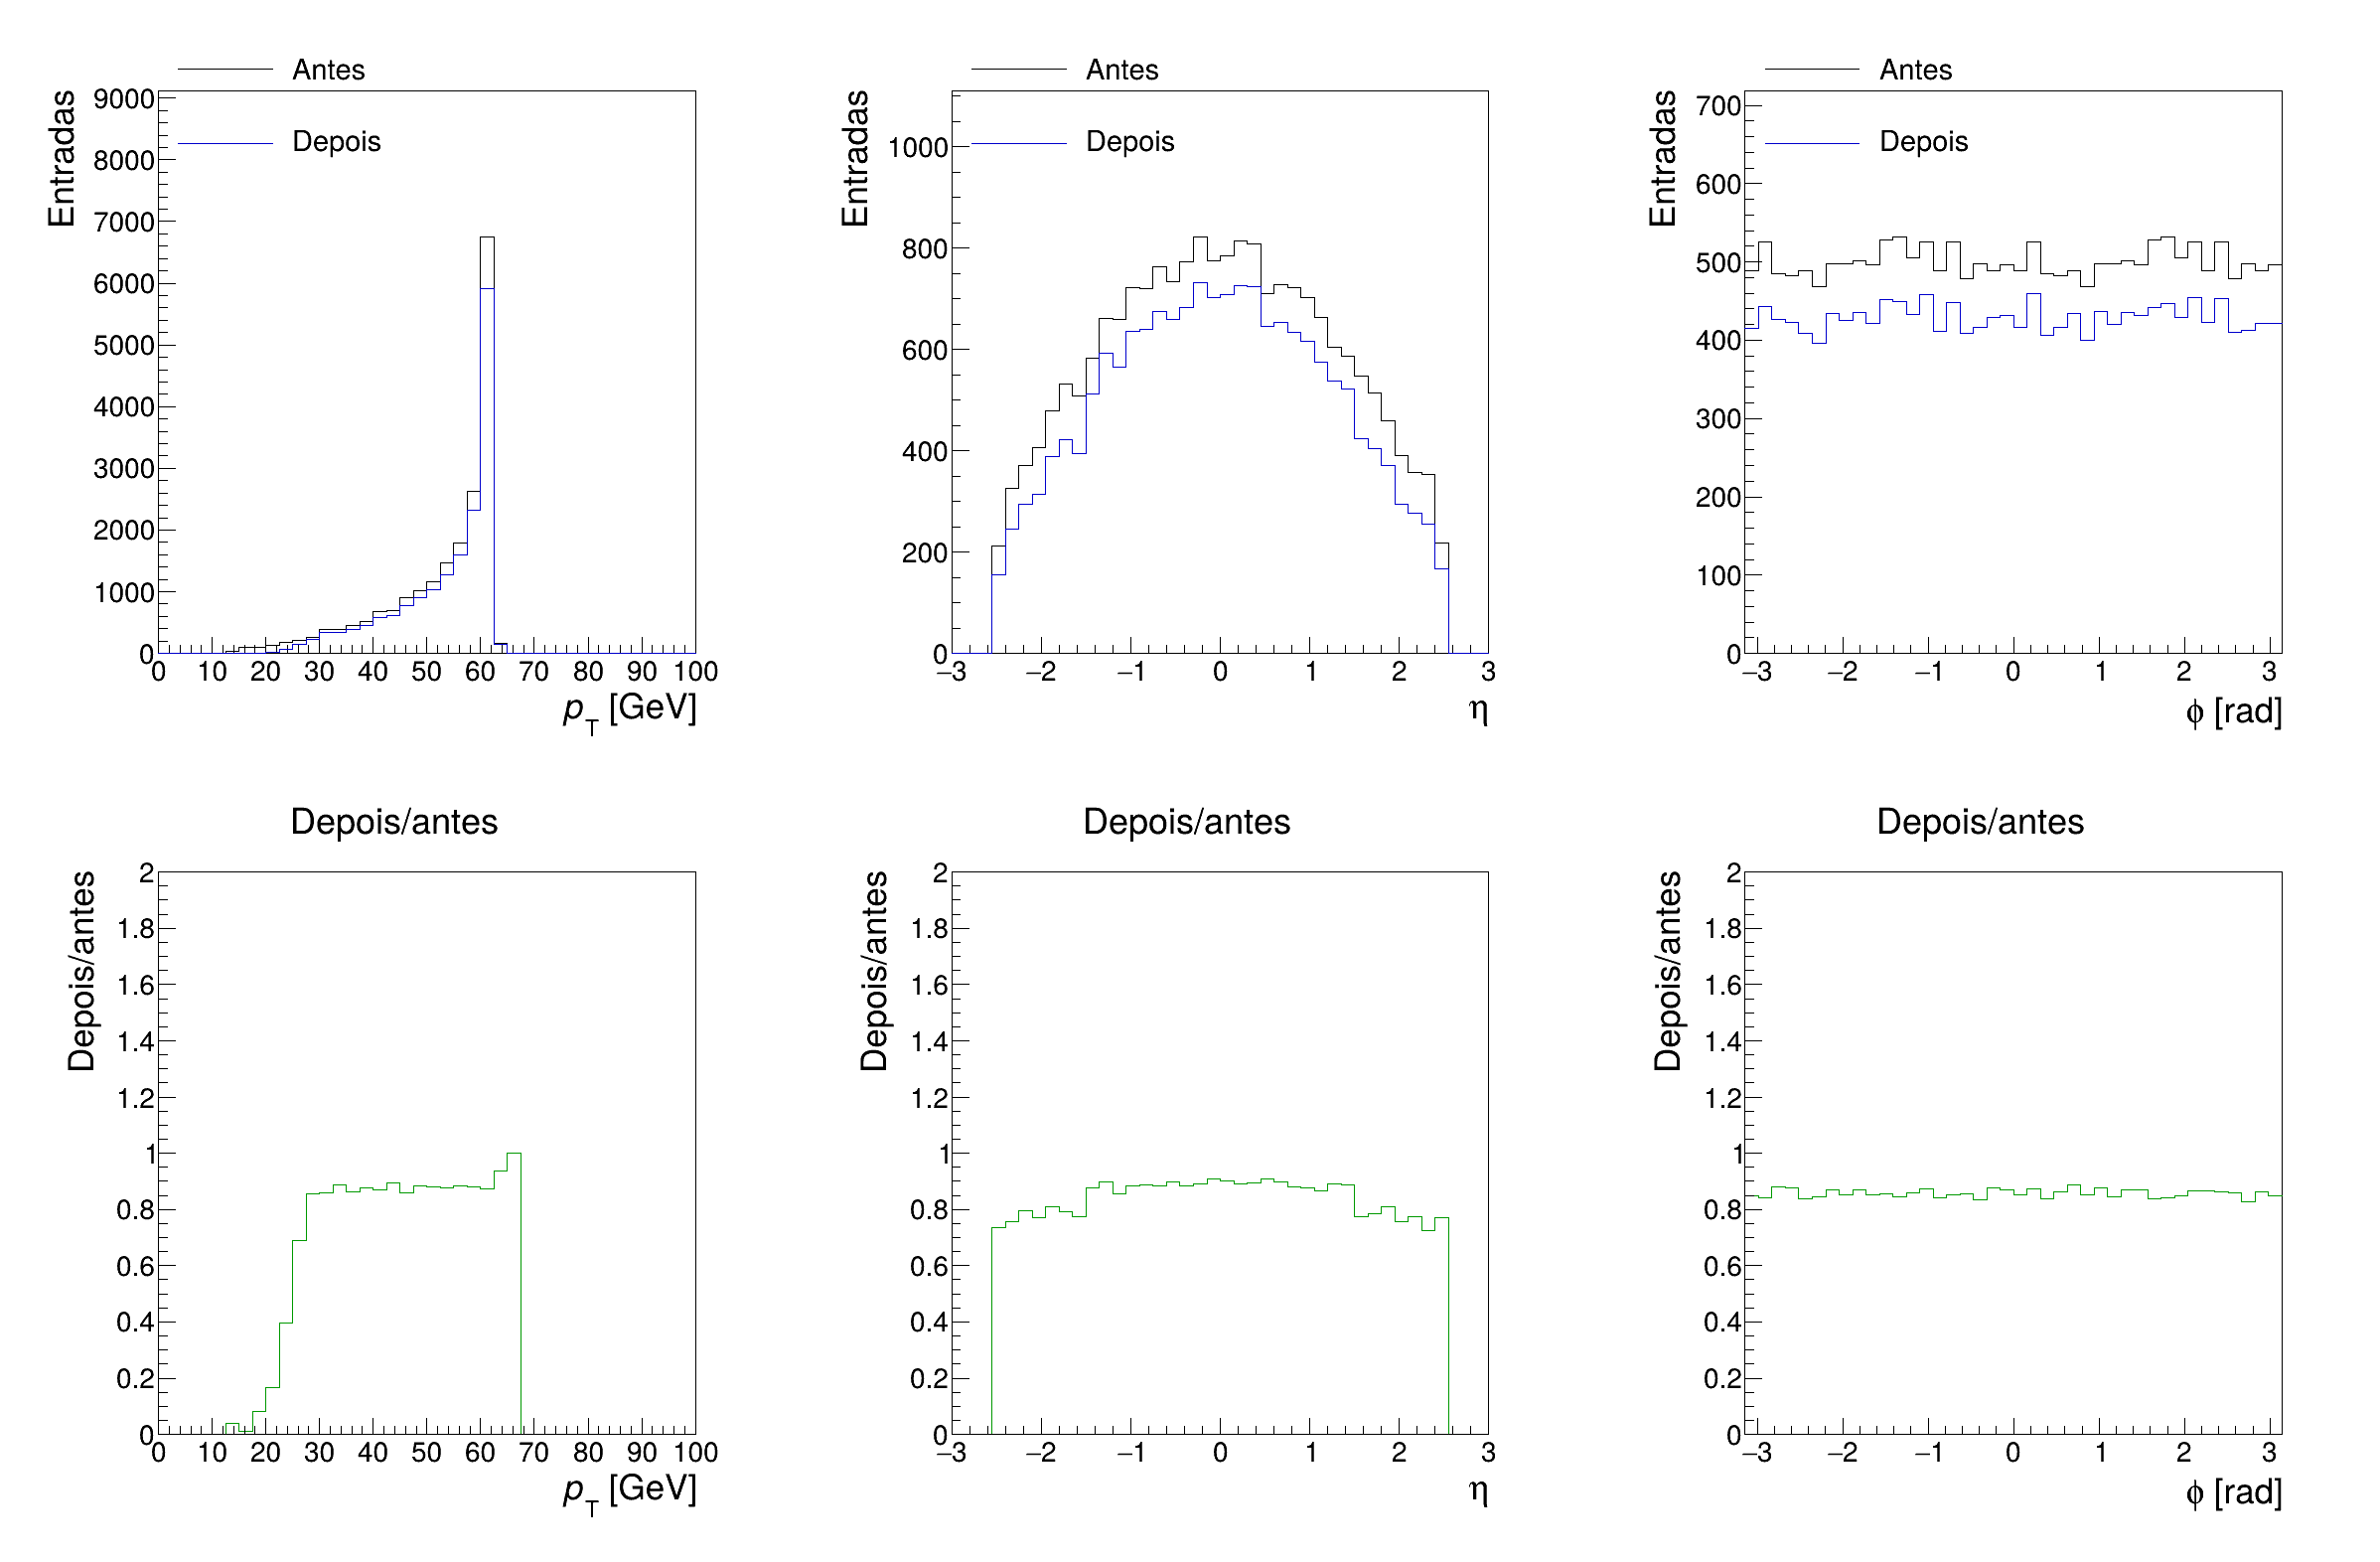

In [28]:
from IPython.display import Image, display

def exibir_png(caminho):
    """Incorpora o PNG gerado pelo ROOT no notebook."""
    display(Image(filename=str(caminho), width=1000))


for caminho_png in sorted(PASTA_GRAFICOS.glob("eficiencia_antes_depois_*.png")):
    exibir_png(caminho_png)


## 1. Leitura, metadados e seleção da Parte 1

Reutilizamos os eventos já lidos e recuperamos a seção de choque e seu erro no bloco `<init>`. Assim mantemos a análise autocontida, mas deixamos explícito de onde vem cada escala usada para converter contagens simuladas em eventos esperados.


### Objetivo desta célula

Lê novamente os arquivos compactados e extrai metadados de inicialização e seleção. O resultado fornece os eventos e as seções de choque usadas na normalização.


In [29]:
def abrir_lhe(caminho):
    caminho = Path(caminho)
    if caminho.suffix == ".gz":
        return gzip.open(caminho, "rt", encoding="utf-8", errors="replace")
    return caminho.open("rt", encoding="utf-8", errors="replace")

def extrair_processo_madgraph(caminho):
    trecho = []
    dentro_do_cartao = False
    with abrir_lhe(caminho) as arquivo:
        for linha in arquivo:
            if "<MG5ProcCard>" in linha:
                dentro_do_cartao = True
            elif "</MG5ProcCard>" in linha:
                break
            elif dentro_do_cartao:
                trecho.append(linha)
    comandos = re.findall(r"^\s*generate\s+(.+?)\s*$", "".join(trecho), re.MULTILINE)
    return comandos[-1] if comandos else "processo nao identificado"

def extrair_init(caminho):
    linhas = []
    dentro_init = False
    with abrir_lhe(caminho) as arquivo:
        for linha in arquivo:
            limpa = linha.strip()
            if limpa == "<init>":
                dentro_init = True
                continue
            if limpa == "</init>":
                break
            if dentro_init and limpa and not limpa.startswith("<"):
                linhas.append(limpa)
    feixes = linhas[0].split()
    processo = linhas[1].split()
    return {
        "ebeam1": float(feixes[2]),
        "ebeam2": float(feixes[3]),
        "IDWTUP": int(feixes[8]),
        "NPRUP": int(feixes[9]),
        "sigma_pb": float(processo[0]),
        "erro_sigma_pb": float(processo[1]),
        "peso_maximo": float(processo[2]),
        "LPRUP": int(processo[3]),
    }

def ler_lhe_para_dataframes(arquivos):
    eventos_linhas = []
    particulas_linhas = []
    for amostra, caminho in arquivos.items():
        dentro_evento = False
        esperando_cabecalho = False
        restantes = 0
        indice_evento = 0
        with abrir_lhe(caminho) as arquivo:
            for numero_linha, linha in enumerate(arquivo, start=1):
                linha = linha.strip()
                if linha == "<event>":
                    dentro_evento = True
                    esperando_cabecalho = True
                    indice_evento += 1
                    continue
                if not dentro_evento:
                    continue
                if esperando_cabecalho:
                    if not linha or linha.startswith("#"):
                        continue
                    campos = linha.split()
                    if len(campos) < 6:
                        raise ValueError(f"Cabecalho invalido na linha {numero_linha}")
                    eventos_linhas.append({
                        "Amostra": amostra, "Evento": indice_evento,
                        "NUP": int(campos[0]), "IDPRUP": int(campos[1]),
                        "peso_evento": float(campos[2]), "SCALUP": float(campos[3]),
                        "AQEDUP": float(campos[4]), "AQCDUP": float(campos[5]),
                    })
                    restantes = int(campos[0])
                    esperando_cabecalho = False
                    continue
                if restantes > 0:
                    campos = linha.split()
                    if len(campos) < 13:
                        raise ValueError(f"Particula invalida na linha {numero_linha}")
                    particulas_linhas.append({
                        "Amostra": amostra, "Evento": indice_evento,
                        "PDG ID": int(campos[0]), "status": int(campos[1]),
                        "mae_1": int(campos[2]), "mae_2": int(campos[3]),
                        "cor_1": int(campos[4]), "cor_2": int(campos[5]),
                        "px": float(campos[6]), "py": float(campos[7]),
                        "pz": float(campos[8]), "energia": float(campos[9]),
                        "massa": float(campos[10]), "tempo_vida": float(campos[11]),
                        "spin": float(campos[12]),
                    })
                    restantes -= 1
                    if restantes == 0:
                        dentro_evento = False
    eventos_df = pd.DataFrame(eventos_linhas)
    particulas_df = pd.DataFrame(particulas_linhas)
    particulas_df["pT [GeV]"] = np.hypot(particulas_df["px"], particulas_df["py"])
    particulas_df["eta"] = np.arcsinh(particulas_df["pz"] / particulas_df["pT [GeV]"].replace(0, np.nan))
    particulas_df["phi"] = np.arctan2(particulas_df["py"], particulas_df["px"])
    return eventos_df, particulas_df

@dataclass(frozen=True)
class Particula:
    pdg_id: int
    status: int
    mae_1: int
    mae_2: int
    cor_1: int
    cor_2: int
    px: float
    py: float
    pz: float
    energia: float
    massa: float
    tempo_vida: float
    spin: float
    eficiencia: float = 1.0
    reconstruida: bool = True

    @property
    def pt(self):
        return math.hypot(self.px, self.py)

    @property
    def eta(self):
        if self.pt == 0:
            return math.copysign(math.inf, self.pz)
        return math.asinh(self.pz / self.pt)

    @property
    def phi(self):
        return math.atan2(self.py, self.px)

@dataclass(frozen=True)
class Evento:
    processo_id: int
    peso: float
    escala: float
    alpha_qed: float
    alpha_qcd: float
    particulas: tuple

def converter_dataframes_para_eventos(eventos_df, particulas_df):
    eventos_por_amostra = {}
    for amostra, tabela_eventos in eventos_df.groupby("Amostra", sort=False):
        lista = []
        tabela_particulas_amostra = particulas_df[particulas_df["Amostra"] == amostra]
        for linha_evento in tabela_eventos.itertuples(index=False):
            partes = tabela_particulas_amostra[tabela_particulas_amostra["Evento"] == linha_evento.Evento]
            particulas = tuple(
                Particula(
                    pdg_id=int(linha["PDG ID"]), status=int(linha["status"]),
                    mae_1=int(linha["mae_1"]), mae_2=int(linha["mae_2"]),
                    cor_1=int(linha["cor_1"]), cor_2=int(linha["cor_2"]),
                    px=float(linha["px"]), py=float(linha["py"]), pz=float(linha["pz"]),
                    energia=float(linha["energia"]), massa=float(linha["massa"]),
                    tempo_vida=float(linha["tempo_vida"]), spin=float(linha["spin"]),
                )
                for _, linha in partes.iterrows()
            )
            dados = linha_evento._asdict()
            lista.append(Evento(
                processo_id=int(dados["IDPRUP"]), peso=float(dados["peso_evento"]),
                escala=float(dados["SCALUP"]), alpha_qed=float(dados["AQEDUP"]),
                alpha_qcd=float(dados["AQCDUP"]), particulas=particulas,
            ))
        eventos_por_amostra[amostra] = lista
    return eventos_por_amostra

metadados = {amostra: extrair_init(caminho) for amostra, caminho in ARQUIVOS.items()}
eventos_df, particulas_df = ler_lhe_para_dataframes(ARQUIVOS)
eventos = converter_dataframes_para_eventos(eventos_df, particulas_df)

display(eventos_df.head())
display(particulas_df.head())
for amostra, caminho in ARQUIVOS.items():
    print(f"{amostra}: {extrair_processo_madgraph(caminho)}")
    print(f"  eventos: {len(eventos[amostra]):,}")
    print(f"  sigma = {metadados[amostra]['sigma_pb']:.6g} pb")


,Amostra,Evento,NUP,IDPRUP,peso_evento,SCALUP,AQEDUP,AQCDUP
0,Sinal,1,5,1,0.018607,125.0013,0.007547,0.123507
1,Sinal,2,5,1,0.018607,125.0007,0.007547,0.123507
2,Sinal,3,5,1,0.018607,124.9997,0.007547,0.123507
3,Sinal,4,5,1,0.018607,124.9959,0.007547,0.123508
4,Sinal,5,5,1,0.018607,124.9804,0.007547,0.123510


,Amostra,Evento,PDG ID,status,mae_1,mae_2,cor_1,cor_2,px,py,pz,energia,massa,tempo_vida,spin,pT [GeV],eta,phi
0,Sinal,1,21,-1,0,0,502,501,0.000000,0.000000,103.849954,103.849954,0.000000,0.0,1.0,0.000000,NaN,0.000000
1,Sinal,1,21,-1,0,0,501,502,-0.000000,-0.000000,-37.615172,37.615172,0.000000,0.0,1.0,0.000000,NaN,-3.141593
2,Sinal,1,25,2,1,2,0,0,0.000000,0.000000,66.234782,141.465126,125.001342,0.0,9.0,0.000000,NaN,0.000000
3,Sinal,1,22,1,3,3,0,0,53.205388,-32.691024,36.072332,72.116083,0.000000,0.0,-1.0,62.446107,0.549570,-0.550963
4,Sinal,1,22,1,3,3,0,0,-53.205388,32.691024,30.162450,69.349043,0.000000,0.0,-1.0,62.446107,0.465969,2.590630


Sinal: p p > h > a a
  eventos: 10,000
  sigma = 0.018607 pb
Fundo: p p > a a / h
  eventos: 10,000
  sigma = 149.05 pb


### Tabelas explícitas para Sinal e Fundo

A tabela é exibida para as duas amostras, depois que as funções e metadados da Parte 2 foram definidos.


In [30]:
resumo_amostras_parte2 = pd.DataFrame([
    {
        "Amostra": amostra,
        "Processo": extrair_processo_madgraph(ARQUIVOS[amostra]),
        "Eventos": len(eventos[amostra]),
        "sigma [pb]": metadados[amostra]["sigma_pb"],
        "erro sigma [pb]": metadados[amostra]["erro_sigma_pb"],
    }
    for amostra in ("Sinal", "Fundo")
])
for amostra in ("Sinal", "Fundo"):
    display(resumo_amostras_parte2[resumo_amostras_parte2["Amostra"] == amostra])


,Amostra,Processo,Eventos,sigma [pb],erro sigma [pb]
0,Sinal,p p > h > a a,10000,0.018607,0.000037


,Amostra,Processo,Eventos,sigma [pb],erro sigma [pb]
1,Fundo,p p > a a / h,10000,149.05,0.26141


### Objetivo desta célula

Define as funções de quadrimomento, massa invariante e seleção final do par γγ. O resultado permite testar conservação, reconstruir massas e repetir a seleção da Parte 1.


In [31]:
NOMES_PDG = {
    25: "H", 23: "Z", 22: "γ", 21: "g", 5: "b", -5: "bbar",
    4: "c", -4: "cbar", 3: "s", -3: "sbar",
    2: "u", -2: "ubar", 1: "d", -1: "dbar",
}

def nome_particula(pdg_id):
    return NOMES_PDG.get(pdg_id, f"PDG {pdg_id}")

def quadrimomento(particula):
    return np.array([particula.energia, particula.px, particula.py, particula.pz], dtype=float)

def soma_quadrimomentos(particulas):
    if not particulas:
        return np.zeros(4)
    return np.sum([quadrimomento(p) for p in particulas], axis=0)

def massa2(vetor):
    energia, px, py, pz = vetor
    return energia**2 - px**2 - py**2 - pz**2

def massa_invariante(particulas):
    return math.sqrt(max(massa2(soma_quadrimomentos(particulas)), 0.0))

def pt_sistema(particulas):
    vetor = soma_quadrimomentos(particulas)
    return math.hypot(vetor[1], vetor[2])

def eta_sistema(particulas):
    vetor = soma_quadrimomentos(particulas)
    pt = math.hypot(vetor[1], vetor[2])
    if pt == 0:
        return math.copysign(math.inf, vetor[3])
    return math.asinh(vetor[3] / pt)

def delta_phi(phi_1, phi_2):
    return (phi_1 - phi_2 + math.pi) % (2 * math.pi) - math.pi

def delta_r(p1, p2):
    return math.hypot(p1.eta - p2.eta, delta_phi(p1.phi, p2.phi))

def particulas_por_status(evento, status):
    return [p for p in evento.particulas if p.status == status]

def finais_visiveis(evento):
    return [p for p in evento.particulas if p.status == 1 and p.reconstruida and abs(p.pdg_id) not in {12, 14, 16}]

def par_fotons(evento):
    return [p for p in finais_visiveis(evento) if abs(p.pdg_id) == 22]

def evento_passa_parte1(evento):
    fotons = par_fotons(evento)
    if len(fotons) != 2:
        return False
    if min(p.pt for p in fotons) <= 25.0 or max(abs(p.eta) for p in fotons) >= 2.5:
        return False
    if delta_r(fotons[0], fotons[1]) <= 0.4:
        return False
    return True

linhas_cutflow = []
for amostra, lista_eventos in eventos.items():
    etapas = [
        ("Sem cortes", lista_eventos),
        ("Topologia esperada", [e for e in lista_eventos if len(par_fotons(e)) == 2]),
        ("Selecao final Parte 1", [e for e in lista_eventos if evento_passa_parte1(e)]),
    ]
    for etapa, selecionados in etapas:
        linhas_cutflow.append({
            "Amostra": amostra,
            "Etapa": etapa,
            "Eventos": len(selecionados),
            "Eficiencia (%)": 100 * len(selecionados) / len(lista_eventos),
        })

cutflow_resumido = pd.DataFrame(linhas_cutflow)
display(cutflow_resumido)

,Amostra,Etapa,Eventos,Eficiencia (%)
0,Sinal,Sem cortes,10000,100.00
1,Sinal,Topologia esperada,10000,100.00
2,Sinal,Selecao final Parte 1,9732,97.32
3,Fundo,Sem cortes,10000,100.00
4,Fundo,Topologia esperada,10000,100.00
5,Fundo,Selecao final Parte 1,1156,11.56


## 2. Conservação do quadrimomento e $\hat{s}$

Conservação do quadrimomento é uma verificação básica de consistência: esperamos $\sum p^\mu_{\rm inicial}\approx\sum p^\mu_{\rm final}$, dentro dos arredondamentos do arquivo. Também calculamos $\hat{s}=(p_1+p_2)^2$, a energia invariante disponível na colisão partônica.


### Objetivo desta célula

Seleciona eventos espaçados ao longo das amostras e compara quadrimomentos iniciais e finais. O resultado quantifica resíduos de conservação e distingue s_hat de m_visível².


In [32]:
indices = [1 + 1000 * i for i in range(10)]
linhas = []
for amostra, lista_eventos in eventos.items():
    for indice in indices:
        evento = lista_eventos[indice - 1]
        iniciais = particulas_por_status(evento, -1)
        finais = particulas_por_status(evento, 1)
        visiveis = finais_visiveis(evento)
        p_inicial = soma_quadrimomentos(iniciais)
        p_final = soma_quadrimomentos(finais)
        p_visivel = soma_quadrimomentos(visiveis)
        residuo = p_inicial - p_final
        linhas.append({
            "Amostra": amostra,
            "Evento": indice,
            "s_hat inicial [GeV^2]": massa2(p_inicial),
            "m2 finais [GeV^2]": massa2(p_final),
            "m2 visivel [GeV^2]": massa2(p_visivel),
            "max |Delta p_mu| [GeV]": np.max(np.abs(residuo)),
        })

consistencia = pd.DataFrame(linhas)
display(consistencia.round(6))
display(
    consistencia.groupby("Amostra")["max |Delta p_mu| [GeV]"]
    .max()
    .rename("Maior residuo nos eventos testados [GeV]")
    .reset_index()
)


,Amostra,Evento,s_hat inicial [GeV^2],m2 finais [GeV^2],m2 visivel [GeV^2],max |Delta p_mu| [GeV]
0,Sinal,1,15625.335487,15625.335486,15625.335486,0.0
1,Sinal,1001,15615.528518,15615.528518,15615.528518,0.0
2,Sinal,2001,15623.624830,15623.624830,15623.624830,0.0
3,Sinal,3001,15628.397286,15628.397286,15628.397286,0.0
4,Sinal,4001,15625.844417,15625.844415,15625.844415,0.0
5,Sinal,5001,15625.502957,15625.502958,15625.502958,0.0
6,Sinal,6001,15624.245327,15624.245327,15624.245327,0.0
7,Sinal,7001,15622.731910,15622.731901,15622.731901,0.0
8,Sinal,8001,15623.300024,15623.300025,15623.300025,0.0
9,Sinal,9001,15626.911328,15626.911328,15626.911328,0.0


,Amostra,Maior residuo nos eventos testados [GeV]
0,Fundo,1.999979e-09
1,Sinal,7.599994e-09


## 3. Massas invariantes e histogramas 2D

A massa invariante de um sistema é calculada por $m^2=(\sum_i E_i)^2-|\sum_i\vec p_i|^2$ e não depende do referencial. Por isso, a massa do par de fótons é um observável natural para procurar uma ressonância; os histogramas 2D ajudam a enxergar correlações com $p_T$.


### Objetivo desta célula

Reconstrói $m_{\gamma\gamma}$, massa visível, $p_T$, $\eta$ e $\Delta R$ dos candidatos aprovados. O resultado produz estatísticas e histogramas 1D/2D para sinal e fundo.


In [33]:
linhas_massas = []
for amostra, lista_eventos in eventos.items():
    for indice, evento in enumerate(lista_eventos, start=1):
        fotons = par_fotons(evento)
        visiveis = finais_visiveis(evento)
        if len(fotons) == 2:
            linhas_massas.append({
                "Amostra": amostra,
                "Evento": indice,
                "Passa selecao": evento_passa_parte1(evento),
                "m_gg [GeV]": massa_invariante(fotons),
                "m_visivel [GeV]": massa_invariante(visiveis),
                "pT_gg [GeV]": pt_sistema(fotons),
                "eta_gg": eta_sistema(fotons),
                "DeltaR_gg": delta_r(fotons[0], fotons[1]),
            })

massas = pd.DataFrame(linhas_massas)
display(massas.groupby("Amostra")[["m_gg [GeV]", "m_visivel [GeV]"]].describe().round(3))

fig, eixos = plt.subplots(1, 2, figsize=(11, 4.2))
variaveis = {
    "m_gg [GeV]": (0, 200, "m_{#gamma#gamma} [GeV]"),
    "m_visivel [GeV]": (0, 200, "m_{visivel} [GeV]"),
}
for eixo, (variavel, (xmin, xmax, rotulo)) in zip(eixos, variaveis.items()):
    for amostra, cor in [("Fundo", "tab:orange"), ("Sinal", "tab:blue")]:
        valores = massas.loc[massas["Amostra"] == amostra, variavel]
        eixo.hist(valores, bins=50, range=(xmin, xmax), histtype="step", linewidth=1.8, label=amostra, color=cor)
    eixo.set_xlabel(rotulo)
    eixo.set_ylabel("Eventos")
    eixo.legend()
fig.tight_layout()
fig.savefig(PASTA_GRAFICOS / "parte2_massas_invariantes_formas.png", dpi=150, bbox_inches="tight")
plt.show()

fig, eixos = plt.subplots(1, 2, figsize=(11, 4.5))
for eixo, amostra in zip(eixos, ["Sinal", "Fundo"]):
    dados = massas[massas["Amostra"] == amostra]
    hist = eixo.hist2d(dados["m_gg [GeV]"], dados["pT_gg [GeV]"], bins=45, range=((80, 180), (0, 0.1)), cmap="viridis")
    eixo.set_xlabel("m_{#gamma#gamma} [GeV]")
    eixo.set_ylabel("#it{p}_{T,#gamma#gamma} [GeV]")
    fig.colorbar(hist[3], ax=eixo, label="Eventos")
fig.tight_layout()
fig.savefig(PASTA_GRAFICOS / "parte2_mgg_vs_ptgg.png", dpi=150, bbox_inches="tight")
plt.show()

m_gg [GeV]                                                      \
             count     mean     std     min      25%      50%      75%   
Amostra                                                                  
Fundo      10000.0   43.040  34.424  20.029   26.078   33.374   47.206   
Sinal      10000.0  124.999   0.633  88.279  124.997  125.000  125.003   

                 m_visivel [GeV]                                             \
             max           count     mean     std     min      25%      50%   
Amostra                                                                       
Fundo    710.673         10000.0   43.040  34.424  20.029   26.078   33.374   
Sinal    166.353         10000.0  124.999   0.633  88.279  124.997  125.000   

                           
             75%      max  
Amostra                    
Fundo     47.206  710.673  
Sinal    125.003  166.353

Warning in <TCanvas::Constructor>: Deleting canvas with same name: c
Info in <TCanvas::Print>: png file /private/var/folders/83/nqg6t5253dzbzhl2t658y2p80000gn/T/tmp.8IWRr49Oyc/resultados/graficos/parte2_massas_invariantes_formas.png has been created


Warning in <TCanvas::Constructor>: Deleting canvas with same name: c


Info in <TCanvas::Print>: png file /private/var/folders/83/nqg6t5253dzbzhl2t658y2p80000gn/T/tmp.8IWRr49Oyc/resultados/graficos/parte2_mgg_vs_ptgg.png has been created


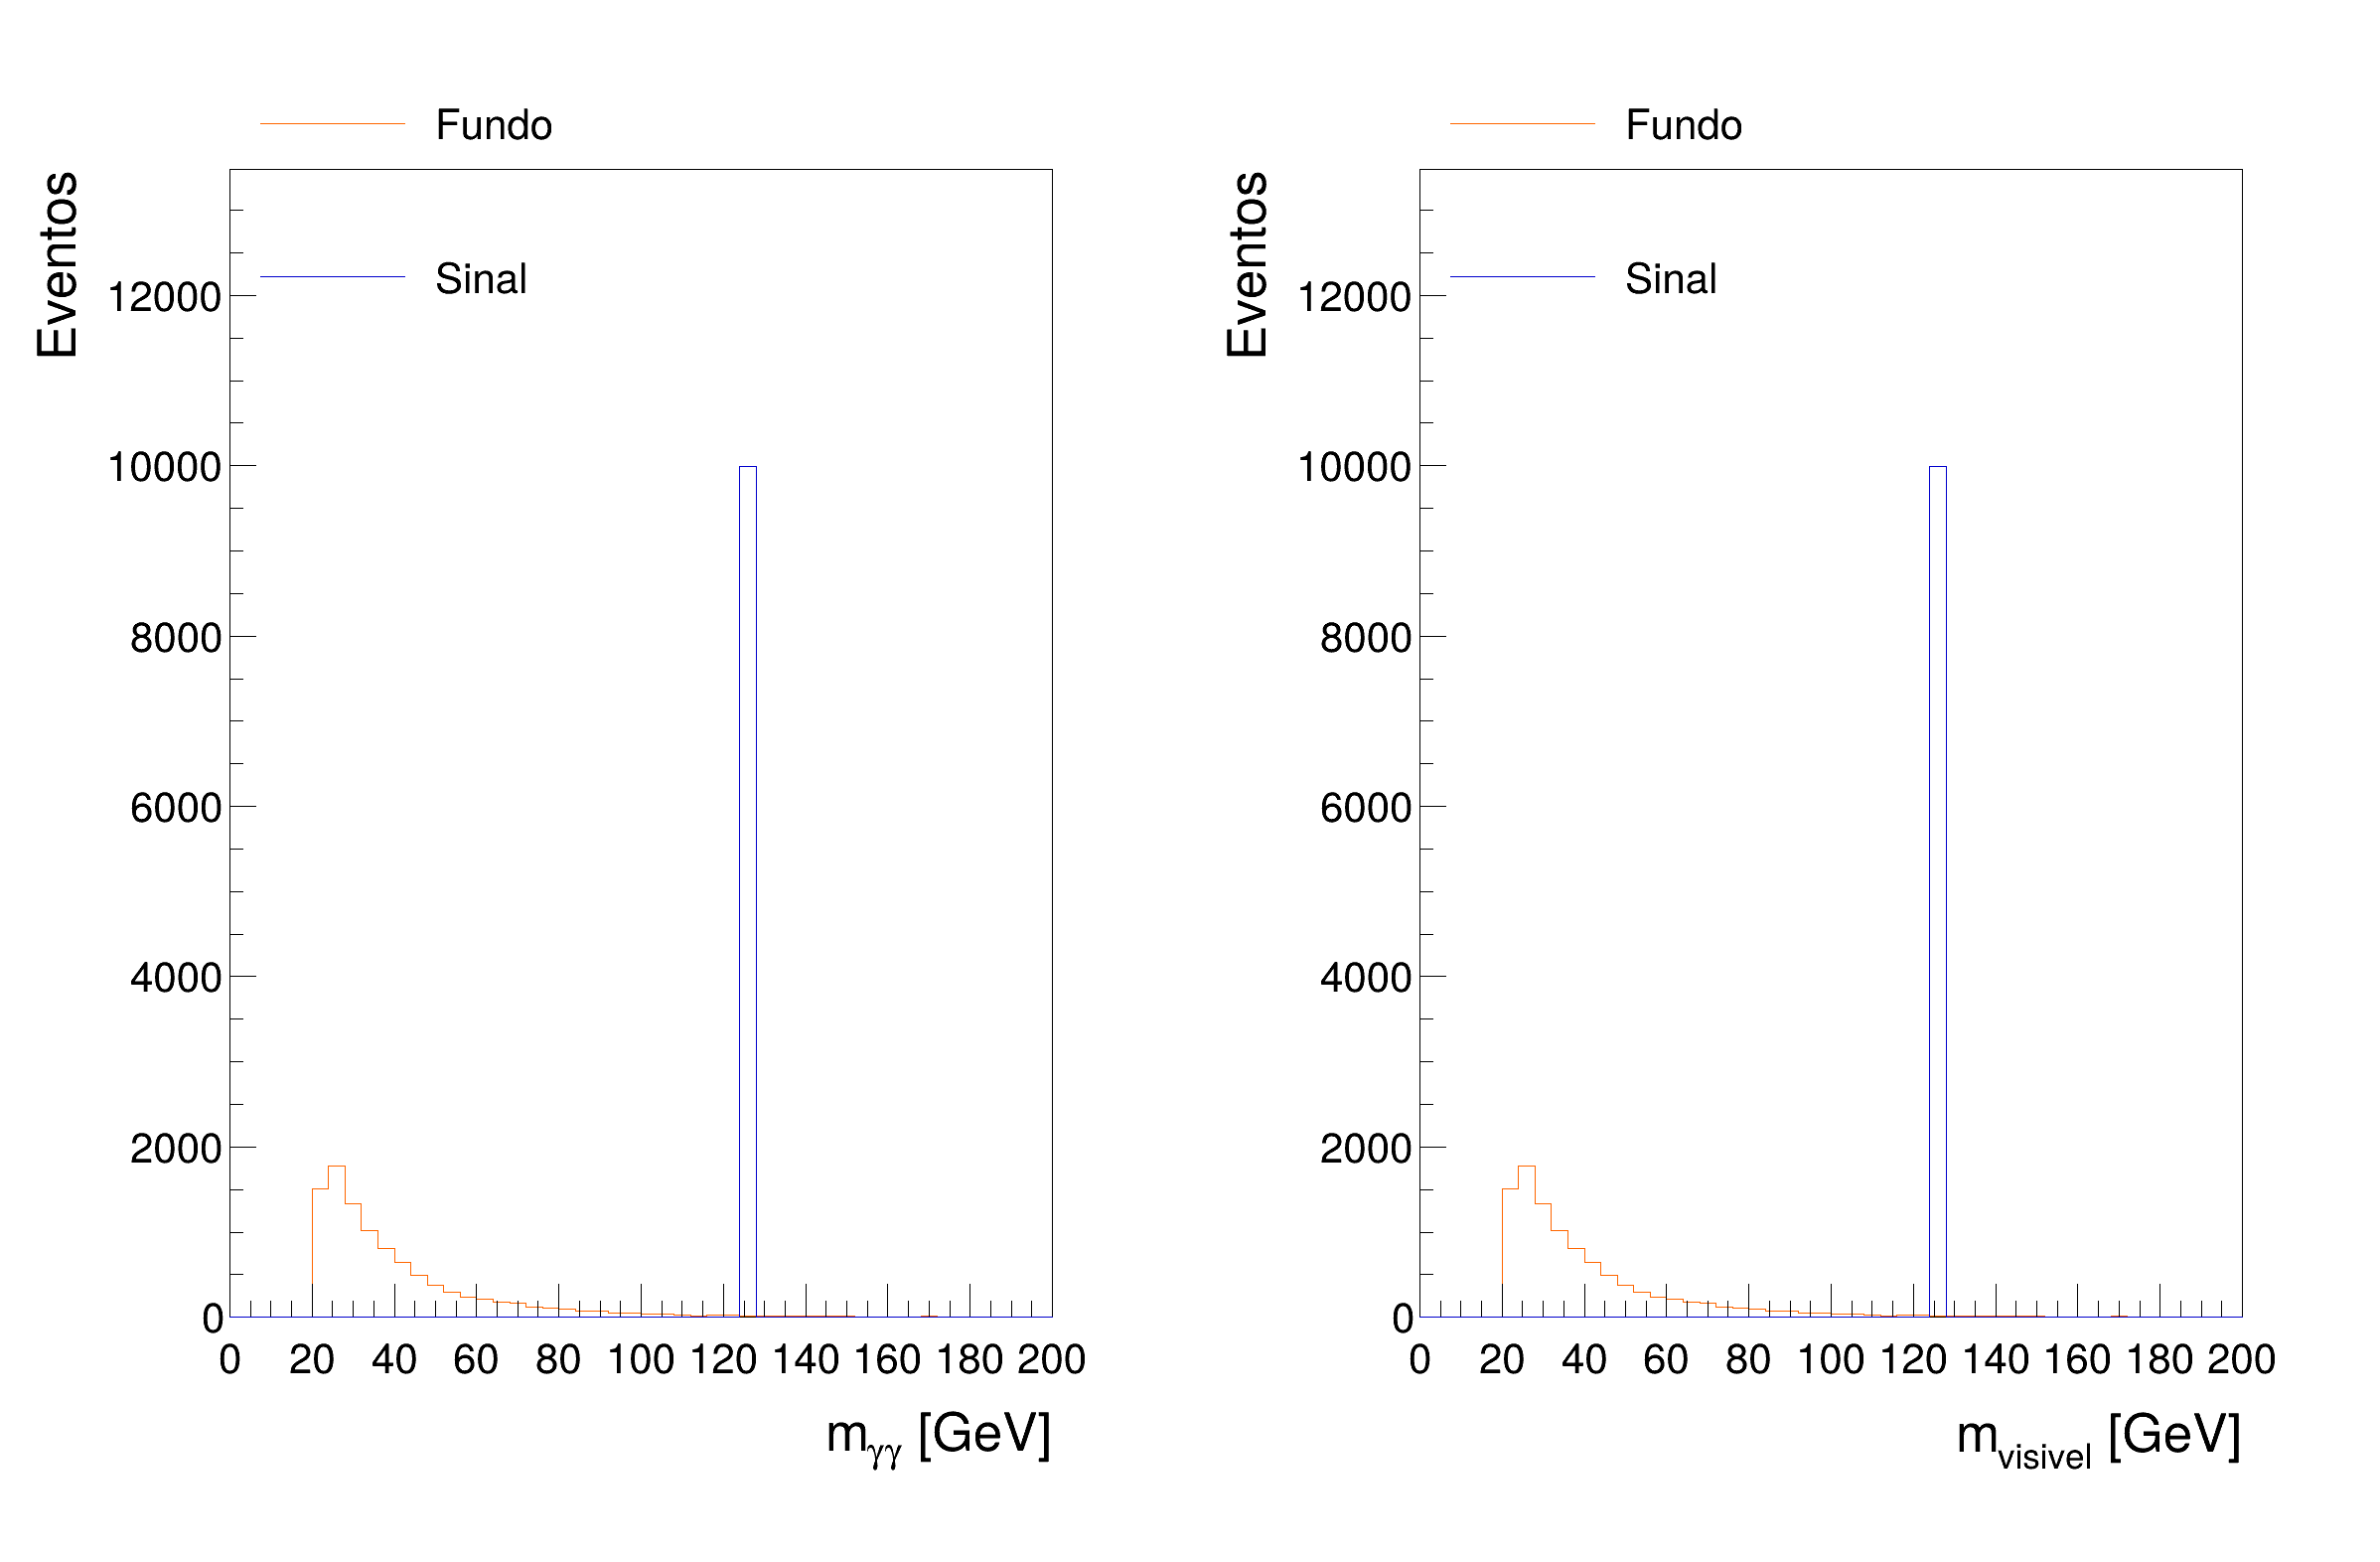

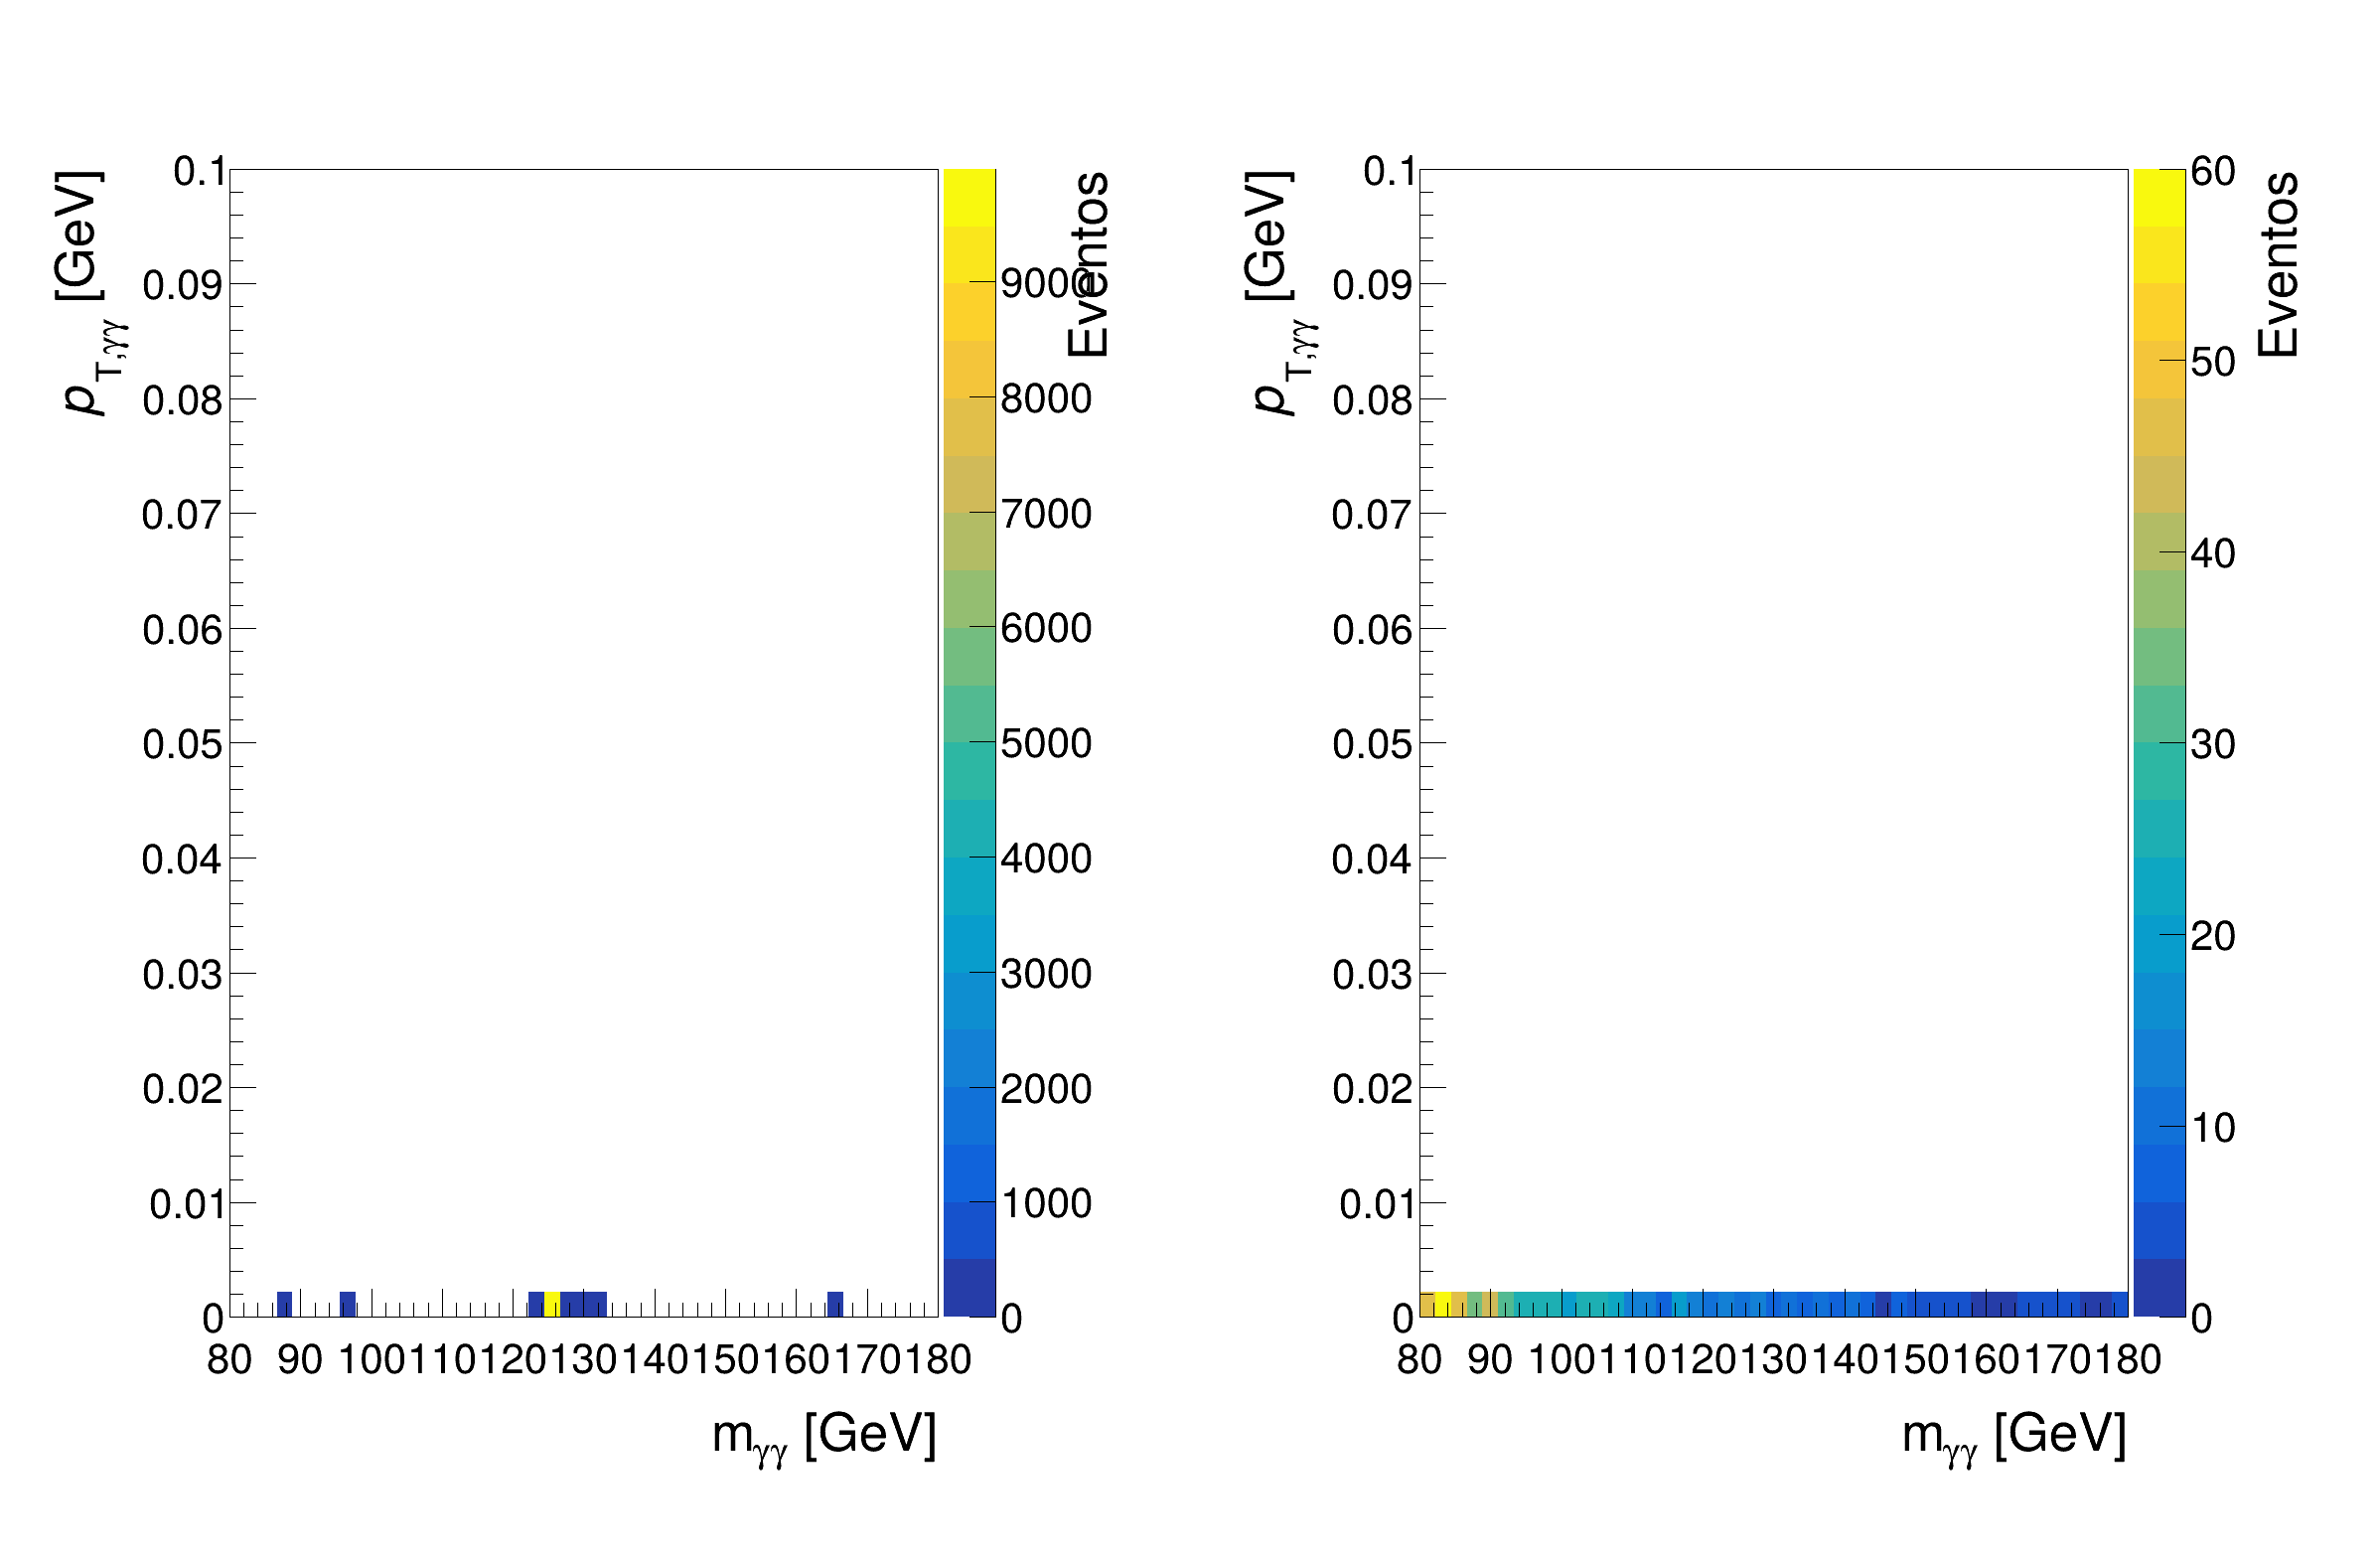

In [34]:
from IPython.display import Image, display

def exibir_png(caminho):
    """Incorpora o PNG gerado pelo ROOT no notebook."""
    display(Image(filename=str(caminho), width=1000))


for nome_png in ("parte2_massas_invariantes_formas.png", "parte2_mgg_vs_ptgg.png"):
    exibir_png(PASTA_GRAFICOS / nome_png)


## 4. Pesos, seção de choque e luminosidade


Os histogramas normalizados usam o peso físico $w=\sigma\,L/N_{\mathrm{gerado}}$ para comparar sinal e fundo na mesma luminosidade.

As amostras podem ter números gerados diferentes, portanto não basta comparar o número bruto de entradas. O peso $w=\sigma\,\mathcal{L}/N_{\mathrm{gerado}}$ coloca cada evento na escala de uma luminosidade comum e faz a soma dos pesos representar o yield esperado.


### Objetivo desta célula

Combina seção de choque, luminosidade e número de eventos gerados para obter os yields normalizados após a seleção. A tabela final resume a sensibilidade esperada da busca:

- `S`: yield esperado de eventos de sinal após os cortes;
- `B`: yield esperado de eventos de fundo após os cortes;
- $S/B$: razão sinal/fundo, que mede a pureza relativa da amostra;
- $S/\sqrt{B}$: significância estatística aproximada, válida como referência quando o fundo é suficientemente grande e as incertezas sistemáticas são desprezadas;
- `S/sqrt(B + (0.10B)^2)`: mesma aproximação incluindo uma incerteza sistemática de 10% no fundo;
- `erro S` e `erro B`: incertezas estatísticas dos yields de sinal e fundo, calculadas a partir das contagens de Monte Carlo e dos pesos físicos.

Essas quantidades são yields esperados para a luminosidade adotada, não contagens diretamente observadas em dados reais.


In [35]:
linhas_norm = []
for amostra, lista_eventos in eventos.items():
    sigma = metadados[amostra]["sigma_pb"]
    n_gerado = len(lista_eventos)
    peso_fisico = sigma * LUMINOSIDADE_PB / n_gerado
    aprovados = [e for e in lista_eventos if evento_passa_parte1(e)]
    linhas_norm.append({
        "Amostra": amostra,
        "Eventos gerados": n_gerado,
        "sigma [pb]": sigma,
        "L [pb^-1]": LUMINOSIDADE_PB,
        "peso sigma*L/N": peso_fisico,
        "peso medio da simulacao": np.mean([evento.peso for evento in lista_eventos]),
        "yield total": sigma * LUMINOSIDADE_PB,
        "eventos aprovados": len(aprovados),
        "yield apos selecao": len(aprovados) * peso_fisico,
        "erro estatistico": math.sqrt(len(aprovados)) * peso_fisico,
    })

normalizacao = pd.DataFrame(linhas_norm)
display(normalizacao.round(6))

S = float(normalizacao.loc[normalizacao["Amostra"] == "Sinal", "yield apos selecao"].iloc[0])
B = float(normalizacao.loc[normalizacao["Amostra"] == "Fundo", "yield apos selecao"].iloc[0])
erro_S = float(normalizacao.loc[normalizacao["Amostra"] == "Sinal", "erro estatistico"].iloc[0])
erro_B = float(normalizacao.loc[normalizacao["Amostra"] == "Fundo", "erro estatistico"].iloc[0])
significancia_sb = S / math.sqrt(B) if B > 0 else np.nan
sigma_b_sist = 0.10 * B
significancia_sist = S / math.sqrt(B + sigma_b_sist**2) if B > 0 else np.nan

display(pd.DataFrame([{
    "S": S,
    "B": B,
    "S/B": S / B if B else np.nan,
    "S/sqrt(B)": significancia_sb,
    "S/sqrt(B + (0.10B)^2)": significancia_sist,
    "erro S": erro_S,
    "erro B": erro_B,
}]).round(6))


,Amostra,Eventos gerados,sigma [pb],L [pb^-1],peso sigma*L/N,peso medio da simulacao,yield total,eventos aprovados,yield apos selecao,erro estatistico
0,Sinal,10000,0.018607,10000.0,0.018607,0.018607,186.07,9732,181.083324,1.835597
1,Fundo,10000,149.050000,10000.0,149.050000,149.050000,1490500.00,1156,172301.800000,5067.700000


,S,B,S/B,S/sqrt(B),S/sqrt(B + (0.10B)^2),erro S,erro B
0,181.083324,172301.8,0.001051,0.436248,0.010507,1.835597,5067.7


## 5. Histogramas normalizados separados

A normalização permite comparar diretamente os yields esperados de sinal e fundo.


### Objetivo desta célula

Constrói histogramas normalizados separados para fundo e sinal, ponderados pela expectativa física após os cortes. O fundo aparece preenchido e o sinal como uma linha, permitindo comparar as duas distribuições sem somá-las.


In [36]:
selecionadas = massas[massas["Passa selecao"]].copy()
pesos_por_amostra = {
    linha["Amostra"]: linha["peso sigma*L/N"]
    for _, linha in normalizacao.iterrows()
}
selecionadas["peso"] = selecionadas["Amostra"].map(pesos_por_amostra)

def hist_ponderado(ax, variavel, intervalo, bins=50):
    fundo = selecionadas.loc[selecionadas["Amostra"] == "Fundo", variavel]
    sinal = selecionadas.loc[selecionadas["Amostra"] == "Sinal", variavel]
    wf = np.full(len(fundo), pesos_por_amostra["Fundo"])
    ws = np.full(len(sinal), pesos_por_amostra["Sinal"])
    cont_f, bordas = np.histogram(fundo, bins=bins, range=intervalo, weights=wf)
    cont_s, _ = np.histogram(sinal, bins=bins, range=intervalo, weights=ws)
    err2_f, _ = np.histogram(fundo, bins=bins, range=intervalo, weights=wf**2)
    err2_s, _ = np.histogram(sinal, bins=bins, range=intervalo, weights=ws**2)
    ax.stairs(cont_f, bordas, fill=True, alpha=0.45, color="tab:orange", label="Fundo")
    ax.stairs(cont_s, bordas, fill=False, color="tab:blue", linewidth=1.8, label="Sinal")
    centros = 0.5 * (bordas[:-1] + bordas[1:])
    ax.errorbar(centros, cont_f, yerr=np.sqrt(err2_f), fmt="none", color="tab:orange", linewidth=0.8, capsize=1.5)
    ax.errorbar(centros, cont_s, yerr=np.sqrt(err2_s), fmt="none", color="tab:blue", linewidth=0.8, capsize=1.5)
    ax.set_ylabel("Eventos esperados")
    ax.legend()

fig, eixos = plt.subplots(1, 2, figsize=(11, 4.2), squeeze=False)
for eixo, (variavel, (xmin, xmax, rotulo)) in zip(eixos.flat, variaveis.items()):
    hist_ponderado(eixo, variavel, (xmin, xmax))
    eixo.set_xlabel(rotulo)
fig.suptitle("Expectativa MC normalizada para L = 10/fb após seleção")
fig.tight_layout()
fig.savefig(PASTA_GRAFICOS / "parte2_massas_normalizadas_separadas.png", dpi=150, bbox_inches="tight")
plt.show()


Warning in <TCanvas::Constructor>: Deleting canvas with same name: c


Info in <TCanvas::Print>: png file /private/var/folders/83/nqg6t5253dzbzhl2t658y2p80000gn/T/tmp.8IWRr49Oyc/resultados/graficos/parte2_massas_normalizadas_separadas.png has been created


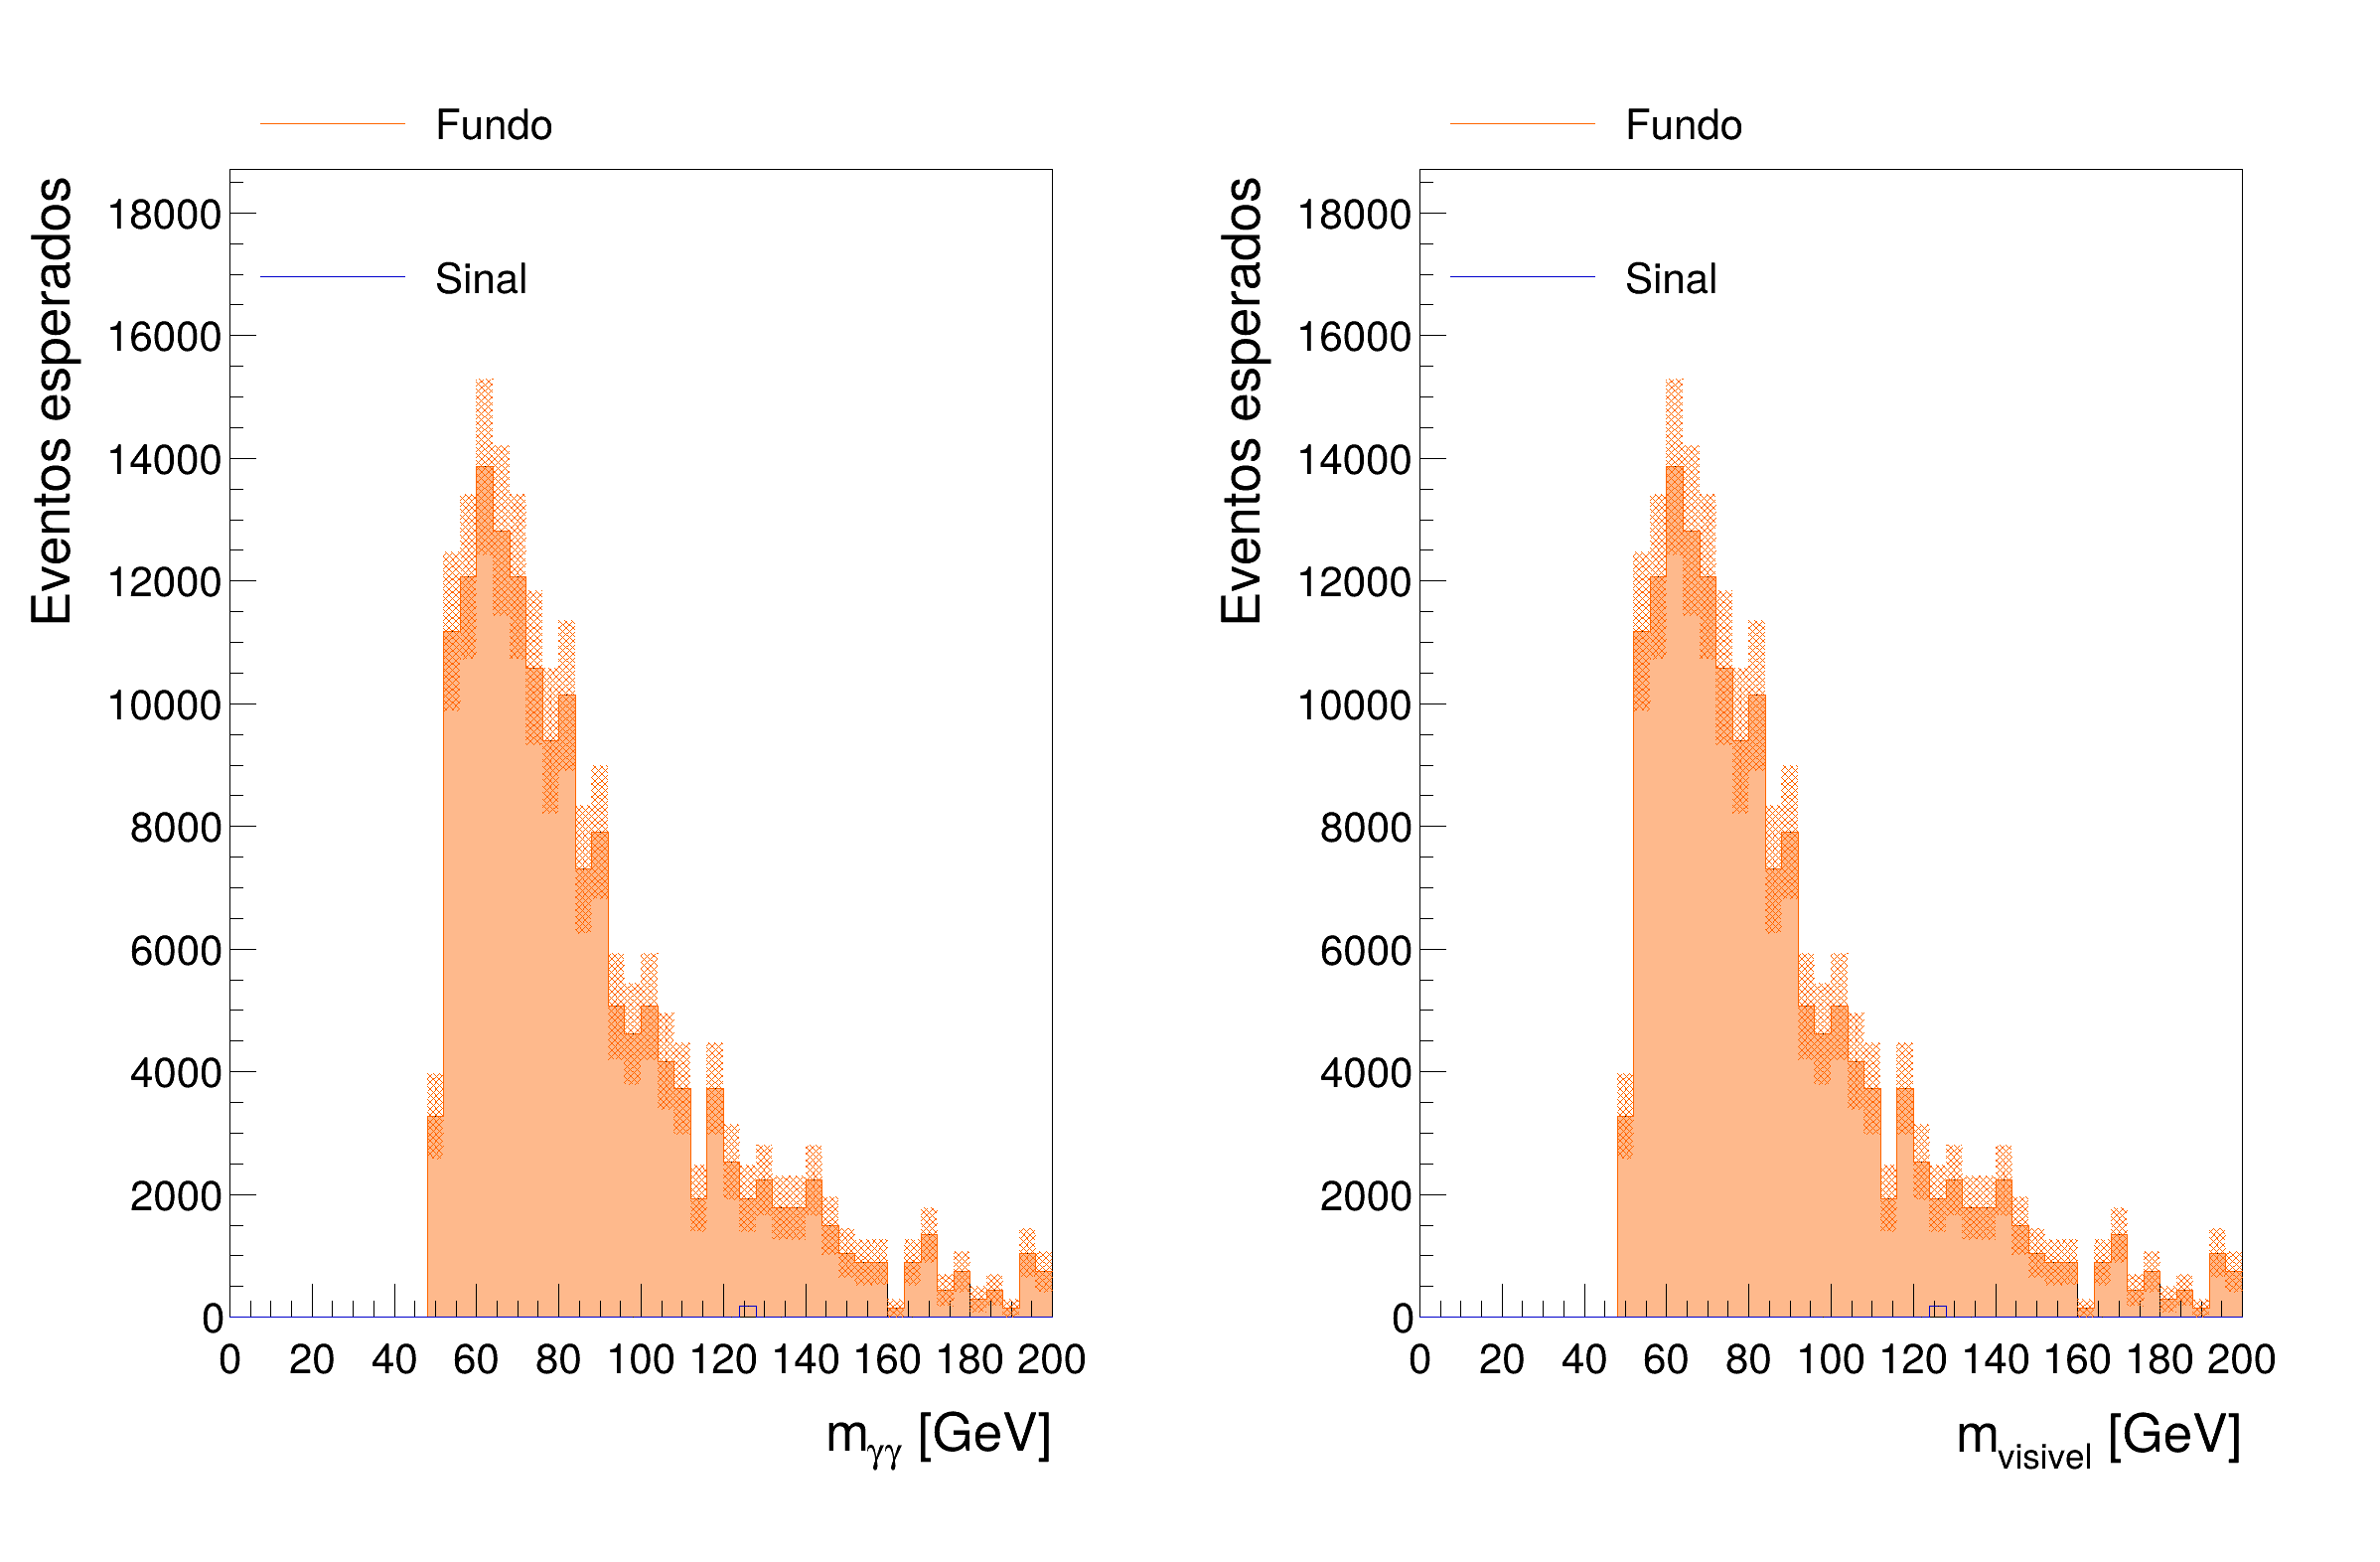

In [37]:
from IPython.display import Image, display

def exibir_png(caminho):
    """Incorpora o PNG gerado pelo ROOT no notebook."""
    display(Image(filename=str(caminho), width=1000))


exibir_png(PASTA_GRAFICOS / "parte2_massas_normalizadas_separadas.png")


## 6. Estimativa simplificada da seção de choque

Depois da seleção, a contagem aprovada pode ser invertida para obter uma estimativa didática: $\hat{\sigma}=N_{\mathrm{pass}}/(A\varepsilon\mathcal{L})$. Compará-la com a seção de choque do LHE mostra por que aceitação e eficiência são indispensáveis.


### Objetivo desta célula

Inverte a relação de yield, aceitação e luminosidade para estimar a seção de choque. O resultado compara a estimativa com a seção de choque registrada no LHE.


In [38]:
linhas_sigma = []
for _, linha in normalizacao.iterrows():
    amostra = linha["Amostra"]
    n_gerado = linha["Eventos gerados"]
    n_pass = linha["eventos aprovados"]
    aceitacao_eficiencia = n_pass / n_gerado
    n_esperado = linha["yield apos selecao"]
    sigma_lhe = linha["sigma [pb]"]
    sigma_estimado = n_esperado / (aceitacao_eficiencia * LUMINOSIDADE_PB)
    linhas_sigma.append({
        "Amostra": amostra,
        "N_gerado": n_gerado,
        "N_pass": n_pass,
        "A*epsilon": aceitacao_eficiencia,
        "N esperado apos selecao": n_esperado,
        "sigma LHE [pb]": sigma_lhe,
        "sigma estimado [pb]": sigma_estimado,
        "diferenca relativa (%)": 100 * (sigma_estimado / sigma_lhe - 1),
    })

estimativa_sigma = pd.DataFrame(linhas_sigma)
display(estimativa_sigma.round(8))


,Amostra,N_gerado,N_pass,A*epsilon,N esperado apos selecao,sigma LHE [pb],sigma estimado [pb],diferenca relativa (%)
0,Sinal,10000,9732,0.9732,181.083324,0.018607,0.018607,0.0
1,Fundo,10000,1156,0.1156,172301.800000,149.050000,149.050000,0.0


## Respostas de referência verificadas nas amostras

Estas amostras representam `sinal.lhe.gz` para `pp → H → γγ` e `fundo.lhe.gz` para o contínuo `pp → γγ`. A validação deve encontrar dois fótons finais por evento; por isso, as variáveis do par de fótons são preenchidas sem `NaN` quando a topologia esperada está presente.

A seleção da Parte 1 aplica cortes ilustrativos em $p_T$, $|\eta|$ e $\Delta R$ dos fótons. Os números de eventos, eficiências, yields e significâncias devem ser obtidos executando as células, pois dependem dos cortes e da luminosidade definidos no notebook.

A massa invariante $m_{\gamma\gamma}$ deve exibir o pico do Higgs próximo de 125 GeV no sinal, enquanto o fundo contínuo produz uma distribuição mais espalhada. A normalização e a estimativa simplificada de seção de choque são checagens didáticas baseadas nos metadados do LHE; não constituem uma medida experimental independente.

Os quatro-momentos continuam em nível de gerador. A Parte 2 acrescenta apenas uma emulação paramétrica e aleatória de eficiência de reconstrução; ela não modela resolução, identificação de fótons, trigger ou pileup reais do detector.

As respostas servem como uma verificação reproduzível, não como números isolados. Cada valor deve poder ser rastreado a uma contagem, a um corte ou a uma fórmula definida nas etapas anteriores.
